In [1]:
"""
mcPHASES — Script 2: Phase-Hypothesis EDA
==========================================
Core hypothesis:
  An individual's physiological BASELINE (stress, sleep, HR, glucose etc.)
  shifts depending on menstrual cycle phase — meaning phase-relative
  deviations matter more than person-level averages.
  Exercise recommendations should therefore adapt to *phase baseline*,
  not just to a static personal mean.

Structure:
  PART 1  — hormones_and_selfreport.csv alone (no join needed)
      1a. Phase label distribution
      1b. Hormone trajectories across phases (LH, estrogen, PDG)
      1c. Self-reported symptom profiles by phase
      1d. Individual participant hormone trajectories (longitudinal)

  PART 2  — After joining wearable signals to hormone/phase table
      2a. Wearable signals (stress, sleep, HR) grouped by phase
      2b. Intra-person phase baseline shift analysis
          → For each participant: does their mean signal DIFFER by phase?
          → Statistical test: repeated-measures / Friedman test per person
      2c. Phase-relative deviation plots
          → signal_centered = signal − person's own phase mean
          → shows whether within-person variance changes by phase
      2d. Exercise signal (active minutes, calories) by phase
          → directly informs the recommendation use-case
"""

"\nmcPHASES — Script 2: Phase-Hypothesis EDA\n==========================================\nCore hypothesis:\n  An individual's physiological BASELINE (stress, sleep, HR, glucose etc.)\n  shifts depending on menstrual cycle phase — meaning phase-relative\n  deviations matter more than person-level averages.\n  Exercise recommendations should therefore adapt to *phase baseline*,\n  not just to a static personal mean.\n\nStructure:\n  PART 1  — hormones_and_selfreport.csv alone (no join needed)\n      1a. Phase label distribution\n      1b. Hormone trajectories across phases (LH, estrogen, PDG)\n      1c. Self-reported symptom profiles by phase\n      1d. Individual participant hormone trajectories (longitudinal)\n\n  PART 2  — After joining wearable signals to hormone/phase table\n      2a. Wearable signals (stress, sleep, HR) grouped by phase\n      2b. Intra-person phase baseline shift analysis\n          → For each participant: does their mean signal DIFFER by phase?\n          → Stati

In [2]:
# ─────────────────────────────────────────────
# 0. IMPORTS & CONFIG
# ─────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare

In [3]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

In [4]:
DATA_DIR = "./data"       # <-- change to your path
OUT_DIR  = "./eda_outputs/script2_phase"
os.makedirs(OUT_DIR, exist_ok=True)

In [5]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, name), bbox_inches="tight")
    plt.show()

In [6]:
def load(fname, **kwargs):
    path = os.path.join(DATA_DIR, fname)
    df   = pd.read_csv(path, **kwargs)
    print(f"  ✓ [{fname}]  shape={df.shape}")
    return df

In [31]:
# Canonical phase order for all plots
PHASE_ORDER = ["menstrual", "follicular", "ovulation", "luteal"]
PHASE_COLORS = {
    "menstrual"  : "#10efe8",
    "follicular" : "#d6ea24",
    "ovulation"  : "#f19f1a",
    "luteal"     : "#ee291b",
}

In [8]:
JOIN_KEYS    = ["id", "day_in_study", "study_interval"]
ID_COL       = "id"
DAY_COL      = "day_in_study"
INTERVAL_COL = "study_interval"

In [9]:
# ─────────────────────────────────────────────
# LOAD TABLES
# ─────────────────────────────────────────────
print("Loading tables …")
hormones    = load("hormones_and_selfreport.csv")
stress      = load("stress_score.csv")
sleep_score = load("sleep_score.csv")
resting_hr  = load("resting_heart_rate.csv")
active_min  = load("active_minutes.csv")
calories    = load("calories.csv")
glucose_df  = load("glucose.csv")
steps_df    = load("steps.csv")

Loading tables …
  ✓ [hormones_and_selfreport.csv]  shape=(5659, 22)
  ✓ [stress_score.csv]  shape=(7932, 14)
  ✓ [sleep_score.csv]  shape=(5308, 12)
  ✓ [resting_heart_rate.csv]  shape=(13737, 6)
  ✓ [active_minutes.csv]  shape=(5552, 8)
  ✓ [calories.csv]  shape=(20166975, 6)
  ✓ [glucose.csv]  shape=(837130, 6)
  ✓ [steps.csv]  shape=(7666949, 6)


In [10]:
# ── Standardise phase labels to lowercase / strip whitespace ─────────────────
if "phase" in hormones.columns:
    hormones["phase"] = (
        hormones["phase"].astype(str).str.strip().str.lower()
    )
    # Keep only known phases
    hormones = hormones[hormones["phase"].isin(PHASE_ORDER)]
    print(f"\nPhase value counts:\n{hormones['phase'].value_counts()}")


Phase value counts:
phase
luteal        1912
follicular    1386
menstrual     1079
Name: count, dtype: int64


In [11]:
# ══════════════════════════════════════════════════════════════
# PART 1 — hormones_and_selfreport.csv ONLY
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PART 1 — HORMONE & SELF-REPORT EDA (no join)")
print("="*60)


PART 1 — HORMONE & SELF-REPORT EDA (no join)


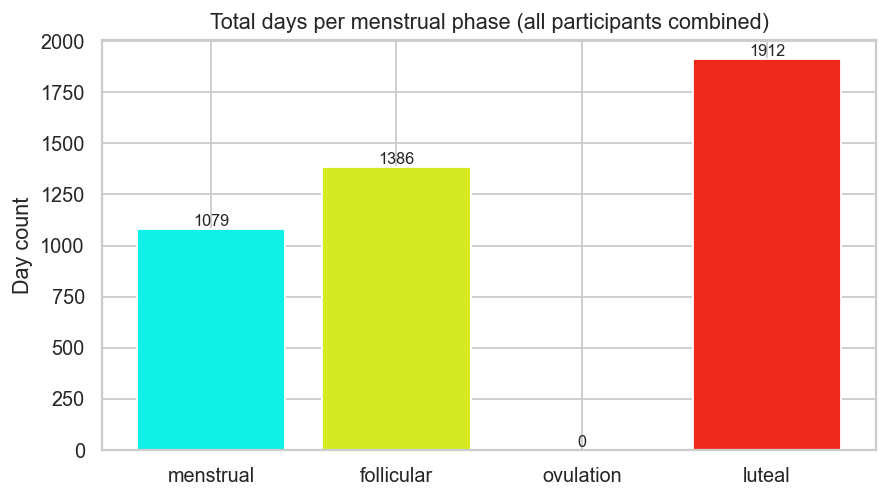

In [33]:
# ── 1a. Phase label distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
counts = hormones["phase"].value_counts().reindex(PHASE_ORDER).fillna(0)
bars   = ax.bar(counts.index, counts.values,
                color=[PHASE_COLORS[p] for p in counts.index])
ax.set_title("Total days per menstrual phase (all participants combined)")
ax.set_ylabel("Day count")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha="center", va="bottom", fontsize=9)
savefig("1a_phase_distribution.png")

In [13]:
# ── 1b. Hormone trajectories across phases ───────────────────────────────────
hormone_cols = ["lh", "estrogen", "pdg"]
hormone_cols = [h for h in hormone_cols if h in hormones.columns]

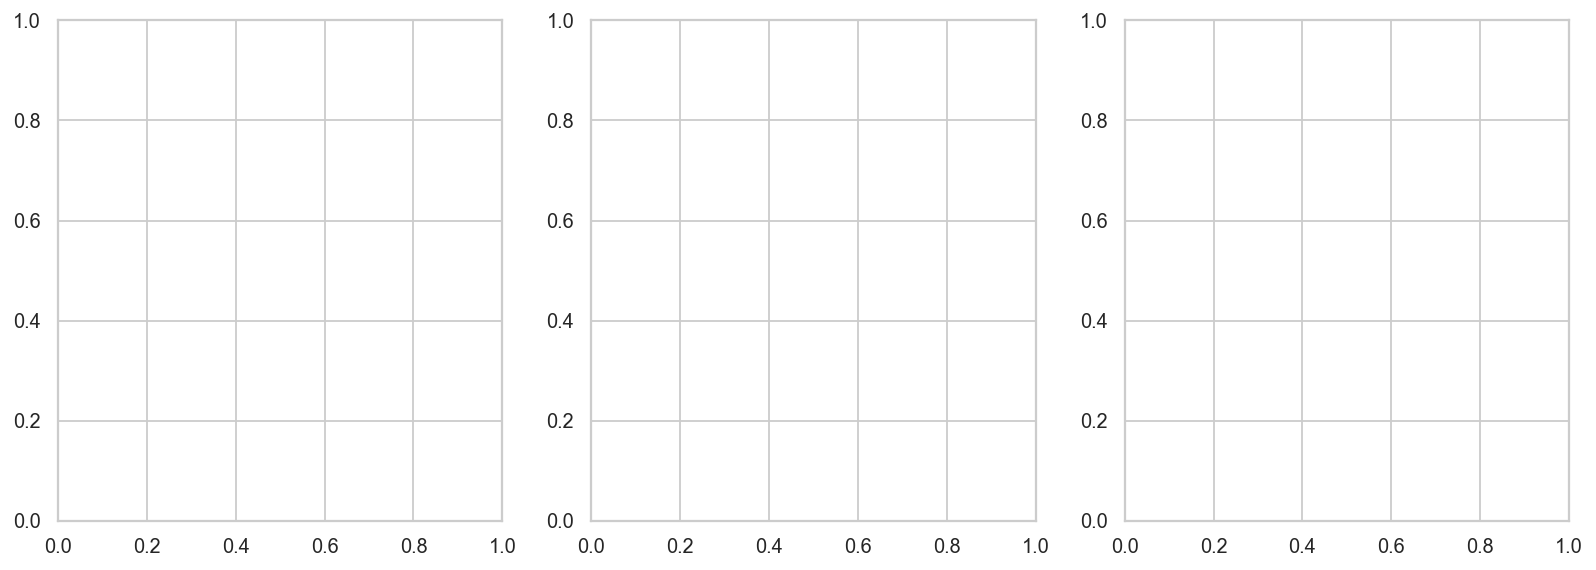

In [14]:
fig, axes = plt.subplots(1, len(hormone_cols), figsize=(5 * len(hormone_cols), 5))
if len(hormone_cols) == 1:
    axes = [axes]

In [15]:
for ax, h in zip(axes, hormone_cols):
    # Box + strip plot to show full distribution, not just mean
    phase_data = [hormones[hormones["phase"] == p][h].dropna()
                  for p in PHASE_ORDER if p in hormones["phase"].unique()]
    ax.boxplot(phase_data,
               labels=[p for p in PHASE_ORDER
                       if p in hormones["phase"].unique()],
               patch_artist=True,
               boxprops=dict(facecolor="#d4e6f1"),
               medianprops=dict(color="red", linewidth=2))

    # Overlay individual points (jittered)
    for i, (p, data) in enumerate(zip(PHASE_ORDER, phase_data), start=1):
        jitter = np.random.normal(0, 0.08, size=len(data))
        ax.scatter(np.full(len(data), i) + jitter, data,
                   alpha=0.25, s=8, color=PHASE_COLORS.get(p, "grey"))

    ax.set_title(f"{h.upper()} by phase", fontsize=10)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Concentration")
    ax.tick_params(axis="x", rotation=20)

In [16]:
plt.suptitle("Hormone distributions across menstrual phases\n"
             "(box = IQR, red line = median, dots = individual readings)",
             fontsize=11, y=1.03)
savefig("1b_hormone_by_phase.png")

<Figure size 832x624 with 0 Axes>

In [17]:
# ── 1c. Self-reported symptom profiles by phase ──────────────────────────────
symptom_cols = ["appetite", "headaches", "cramps", "sorebreasts",
                "fatigue", "sleepissue", "moodswing", "stress",
                "foodcravings", "indigestion", "bloating"]
symptom_cols = [c for c in symptom_cols if c in hormones.columns]

In [18]:
# Radar / spider chart — shows the full symptom profile shape per phase
from matplotlib.patches import FancyArrowPatch
import math

In [19]:
def radar_chart(df, group_col, value_cols, group_order, colors, title, save_name):
    """Draw a radar chart with one polygon per group."""
    N      = len(value_cols)
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8),
                            subplot_kw=dict(polar=True))
    ax.set_theta_offset(math.pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], value_cols, fontsize=9)

    for phase in group_order:
        if phase not in df[group_col].unique():
            continue
        values = df[df[group_col] == phase][value_cols].mean().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2,
                color=colors.get(phase, "grey"), label=phase)
        ax.fill(angles, values, alpha=0.1,
                color=colors.get(phase, "grey"))

    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=7)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
    ax.set_title(title, fontsize=12, y=1.08)
    savefig(save_name)

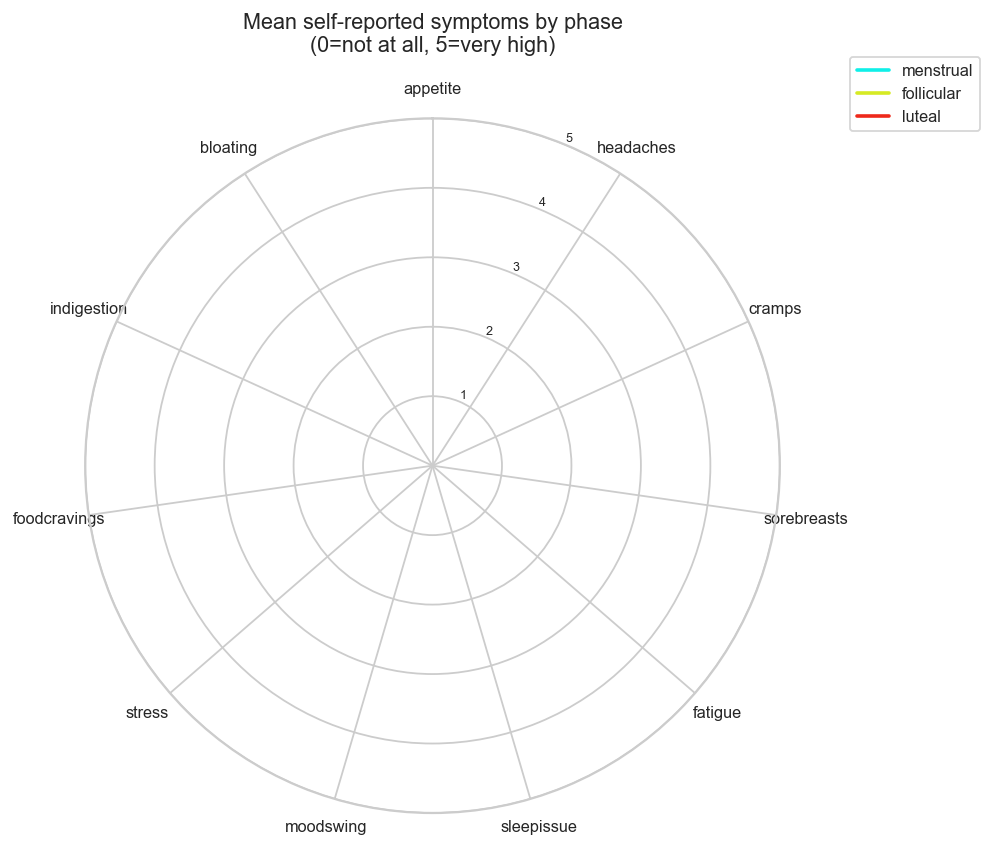

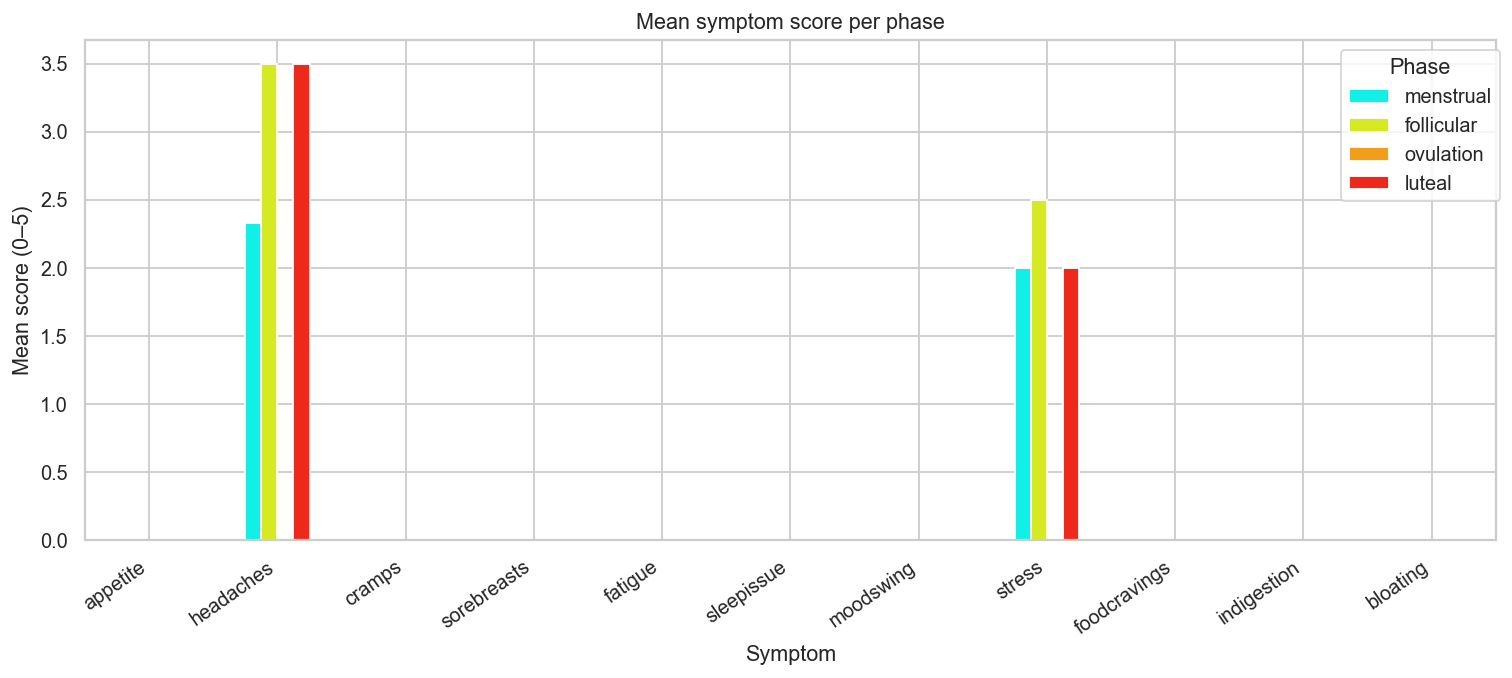

In [34]:
if symptom_cols:
    # Convert symptom columns to numeric, coercing errors to NaN
    hormones[symptom_cols] = hormones[symptom_cols].apply(pd.to_numeric, errors='coerce')

    radar_chart(hormones, "phase", symptom_cols,
                PHASE_ORDER, PHASE_COLORS,
                "Mean self-reported symptoms by phase\n(0=not at all, 5=very high)",
                "1c_symptom_radar.png")

    # Also a grouped bar chart for exact values
    phase_symptom_means = (
        hormones.groupby("phase")[symptom_cols]
                .mean()
                .reindex(PHASE_ORDER)
    )
    fig, ax = plt.subplots(figsize=(14, 5))
    phase_symptom_means.T.plot(
        kind="bar", ax=ax,
        color=[PHASE_COLORS[p] for p in PHASE_ORDER
               if p in phase_symptom_means.index],
        edgecolor="white"
    )
    ax.set_title("Mean symptom score per phase")
    ax.set_ylabel("Mean score (0–5)")
    ax.set_xlabel("Symptom")
    ax.legend(title="Phase", bbox_to_anchor=(1.01, 1))
    plt.xticks(rotation=35, ha="right")
    plt.savefig("1c_symptom_bar.png")

── 1d. Individual participant hormone trajectories ──────────────────────────
HYPOTHESIS PREVIEW: do individual baselines shift by phase?
Plot each participant's LH, estrogen, PDG across their study days,
colour-coded by phase.

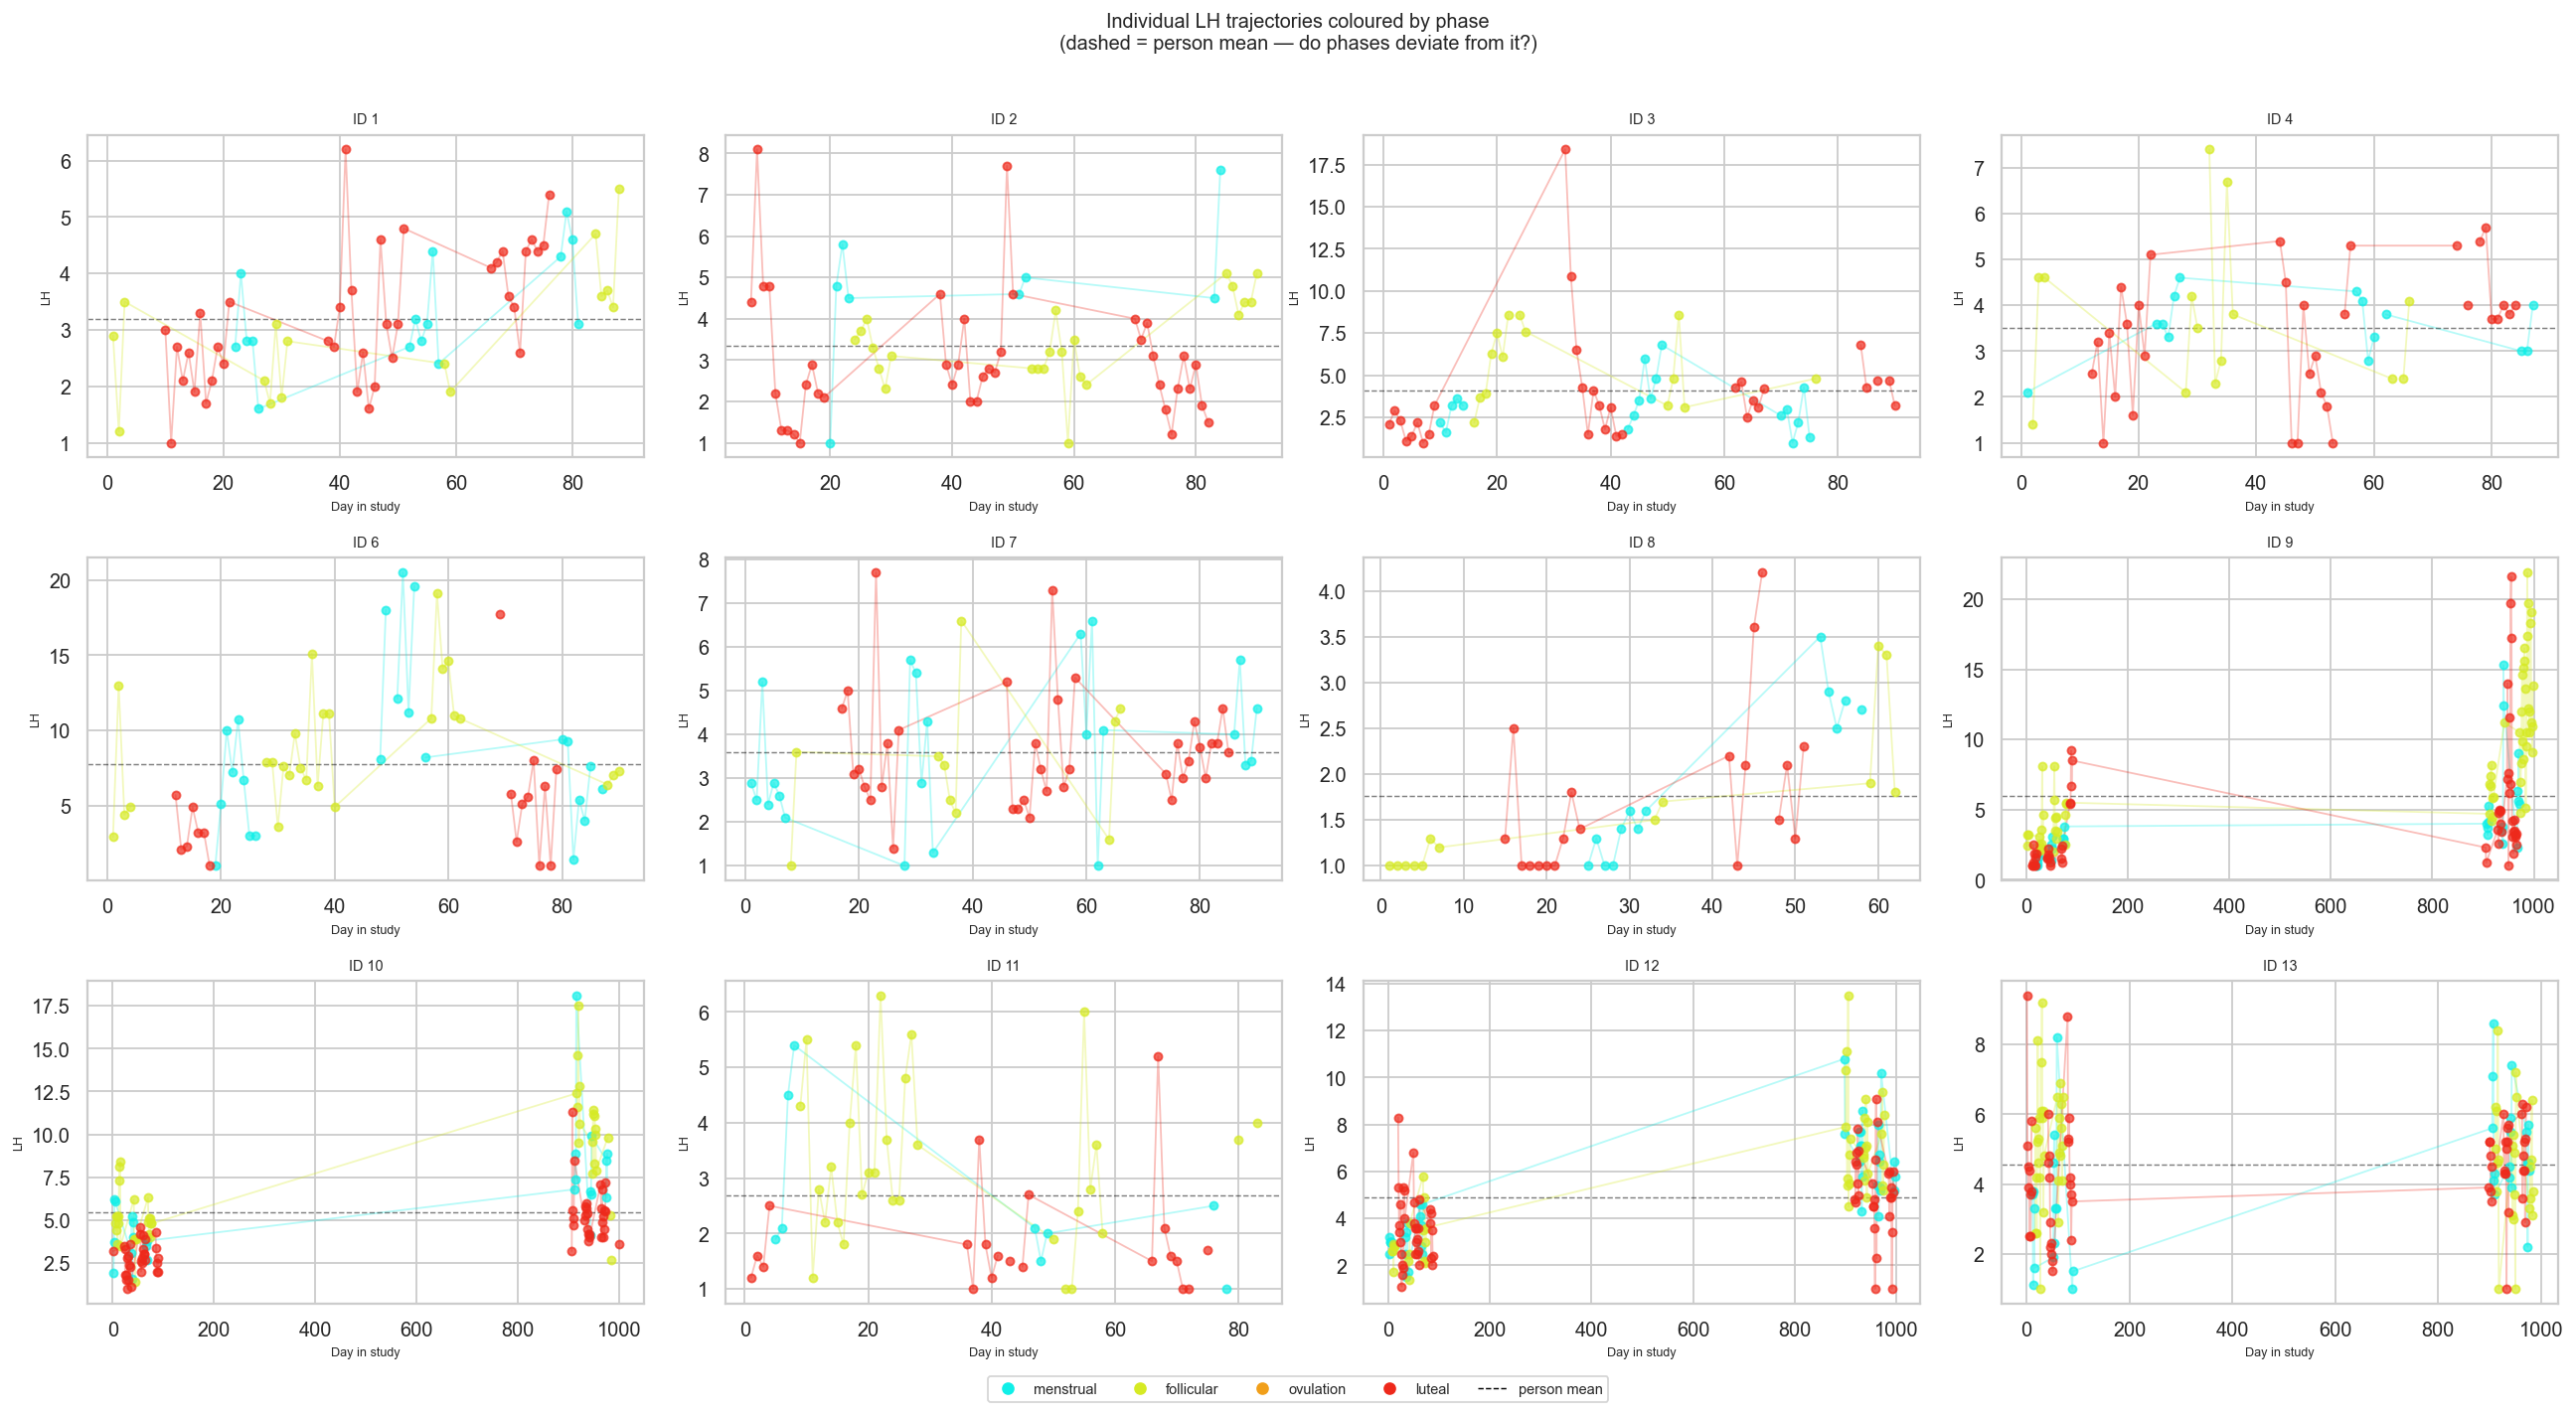

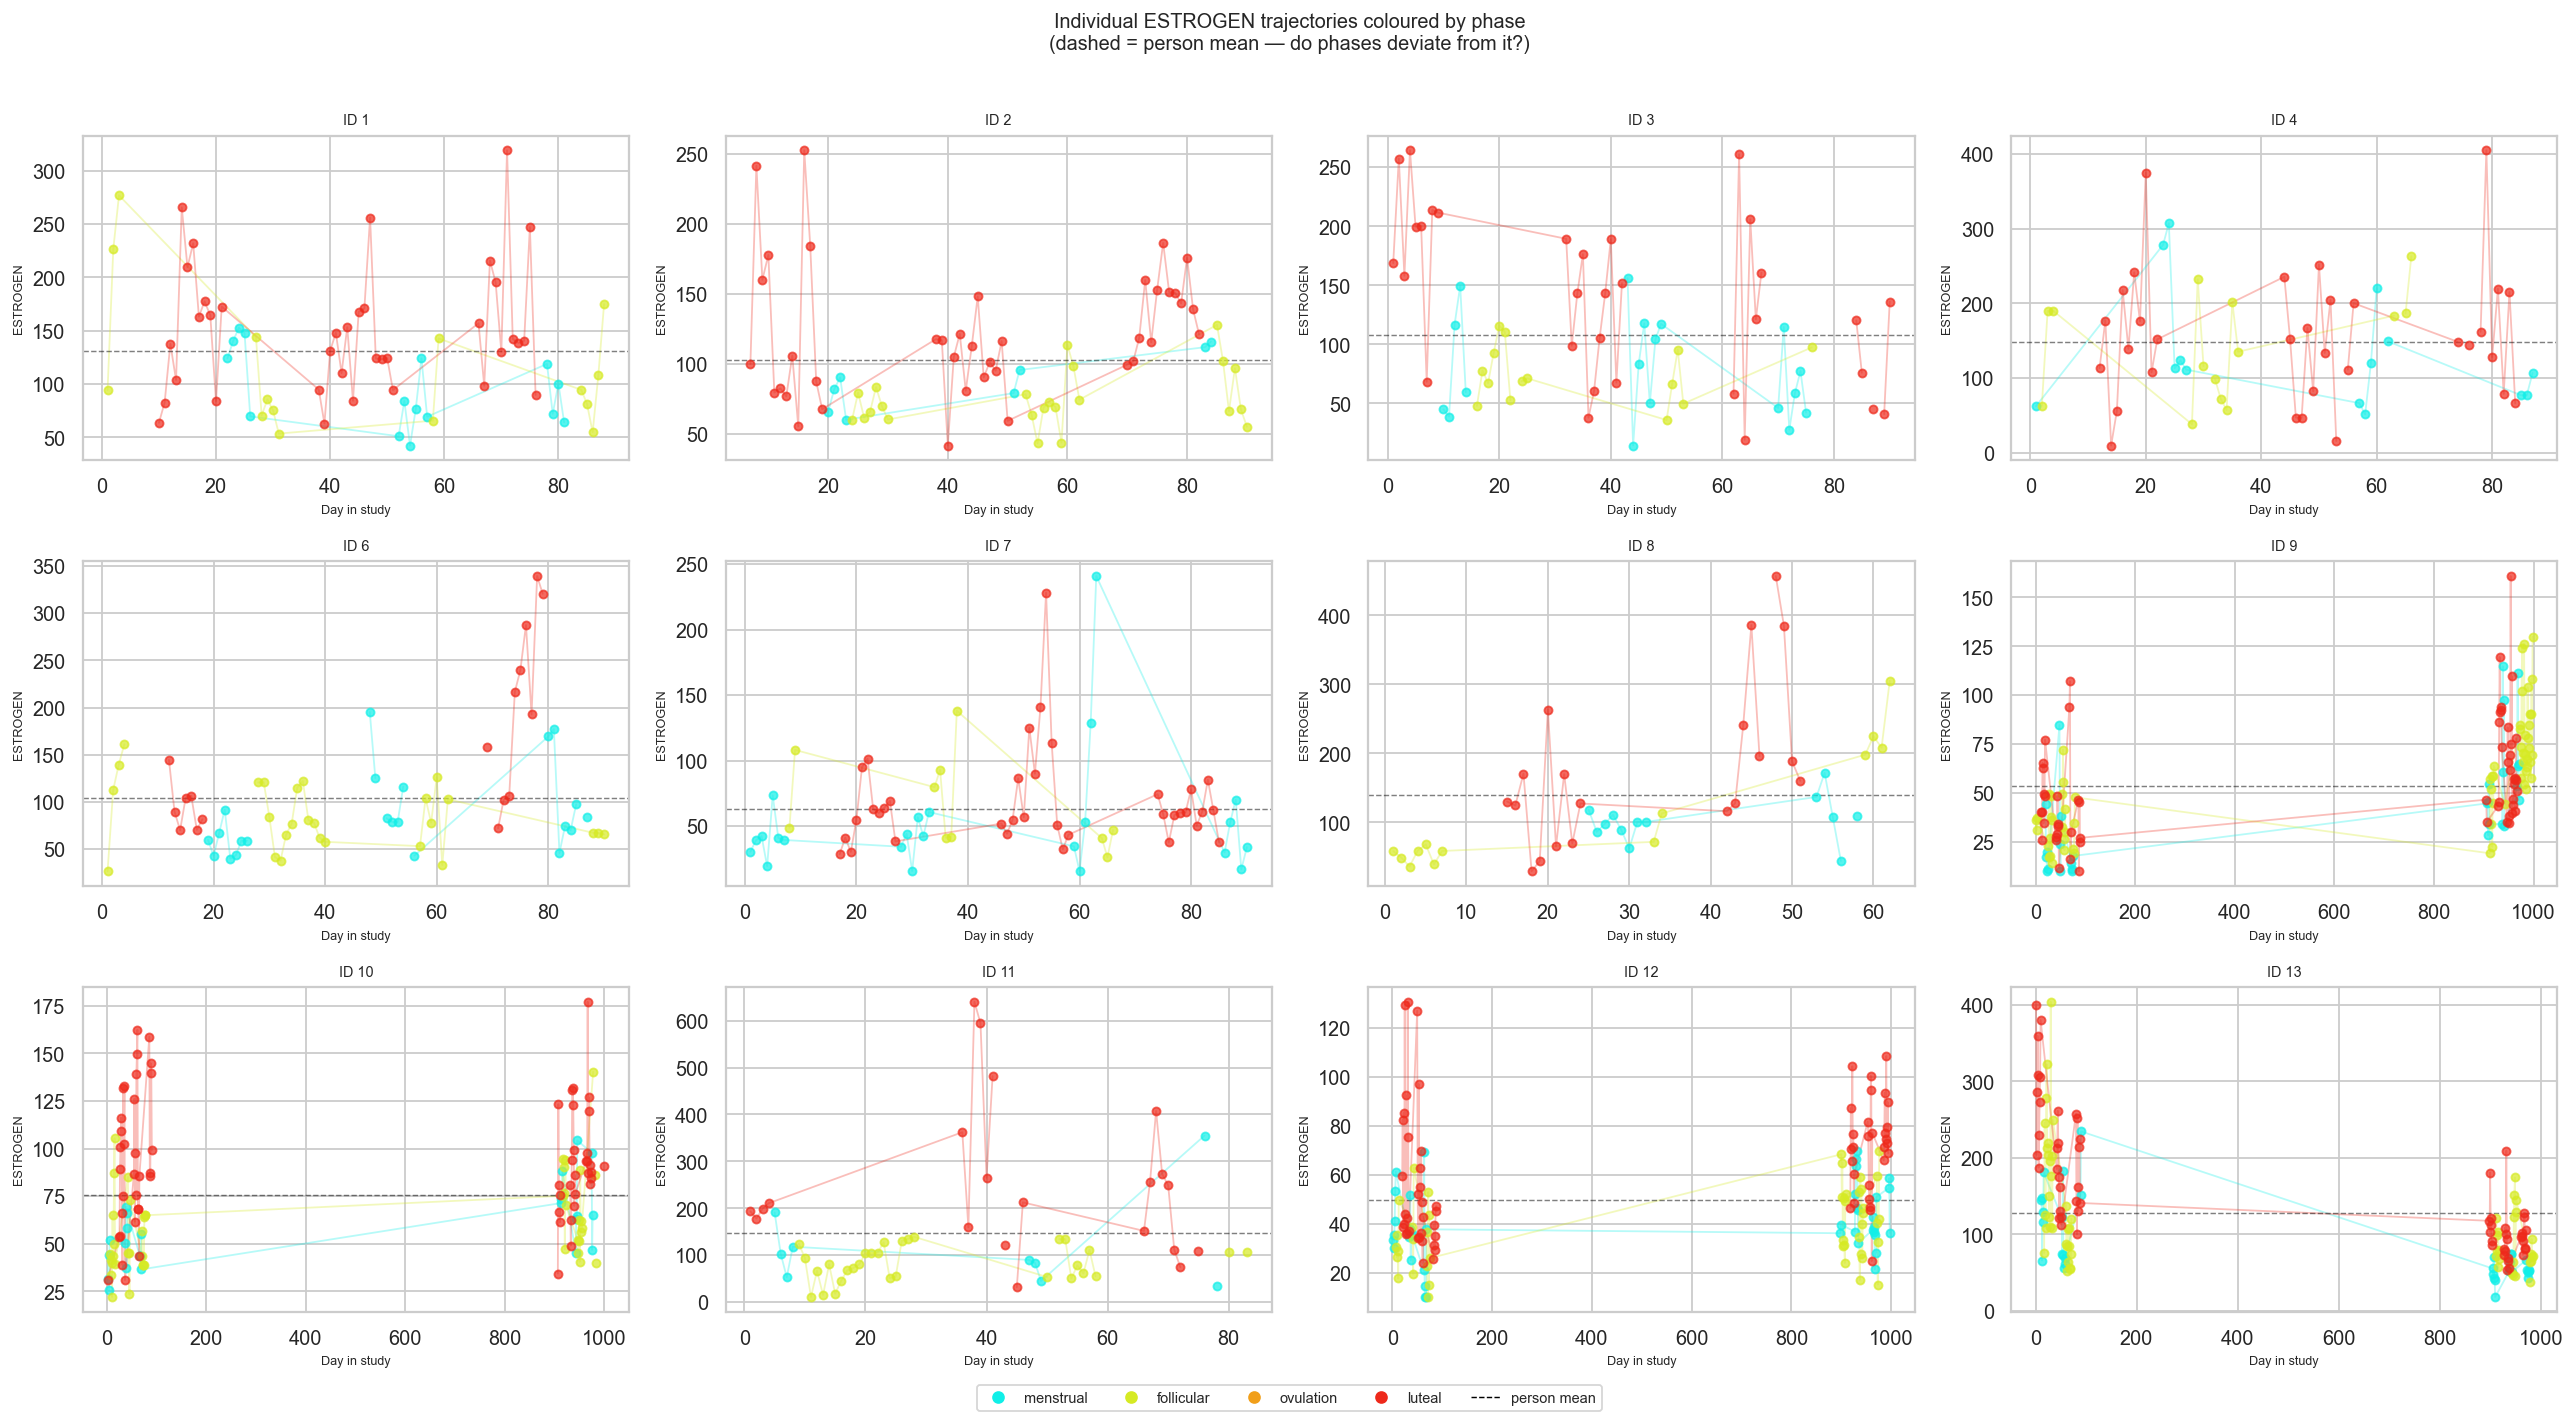

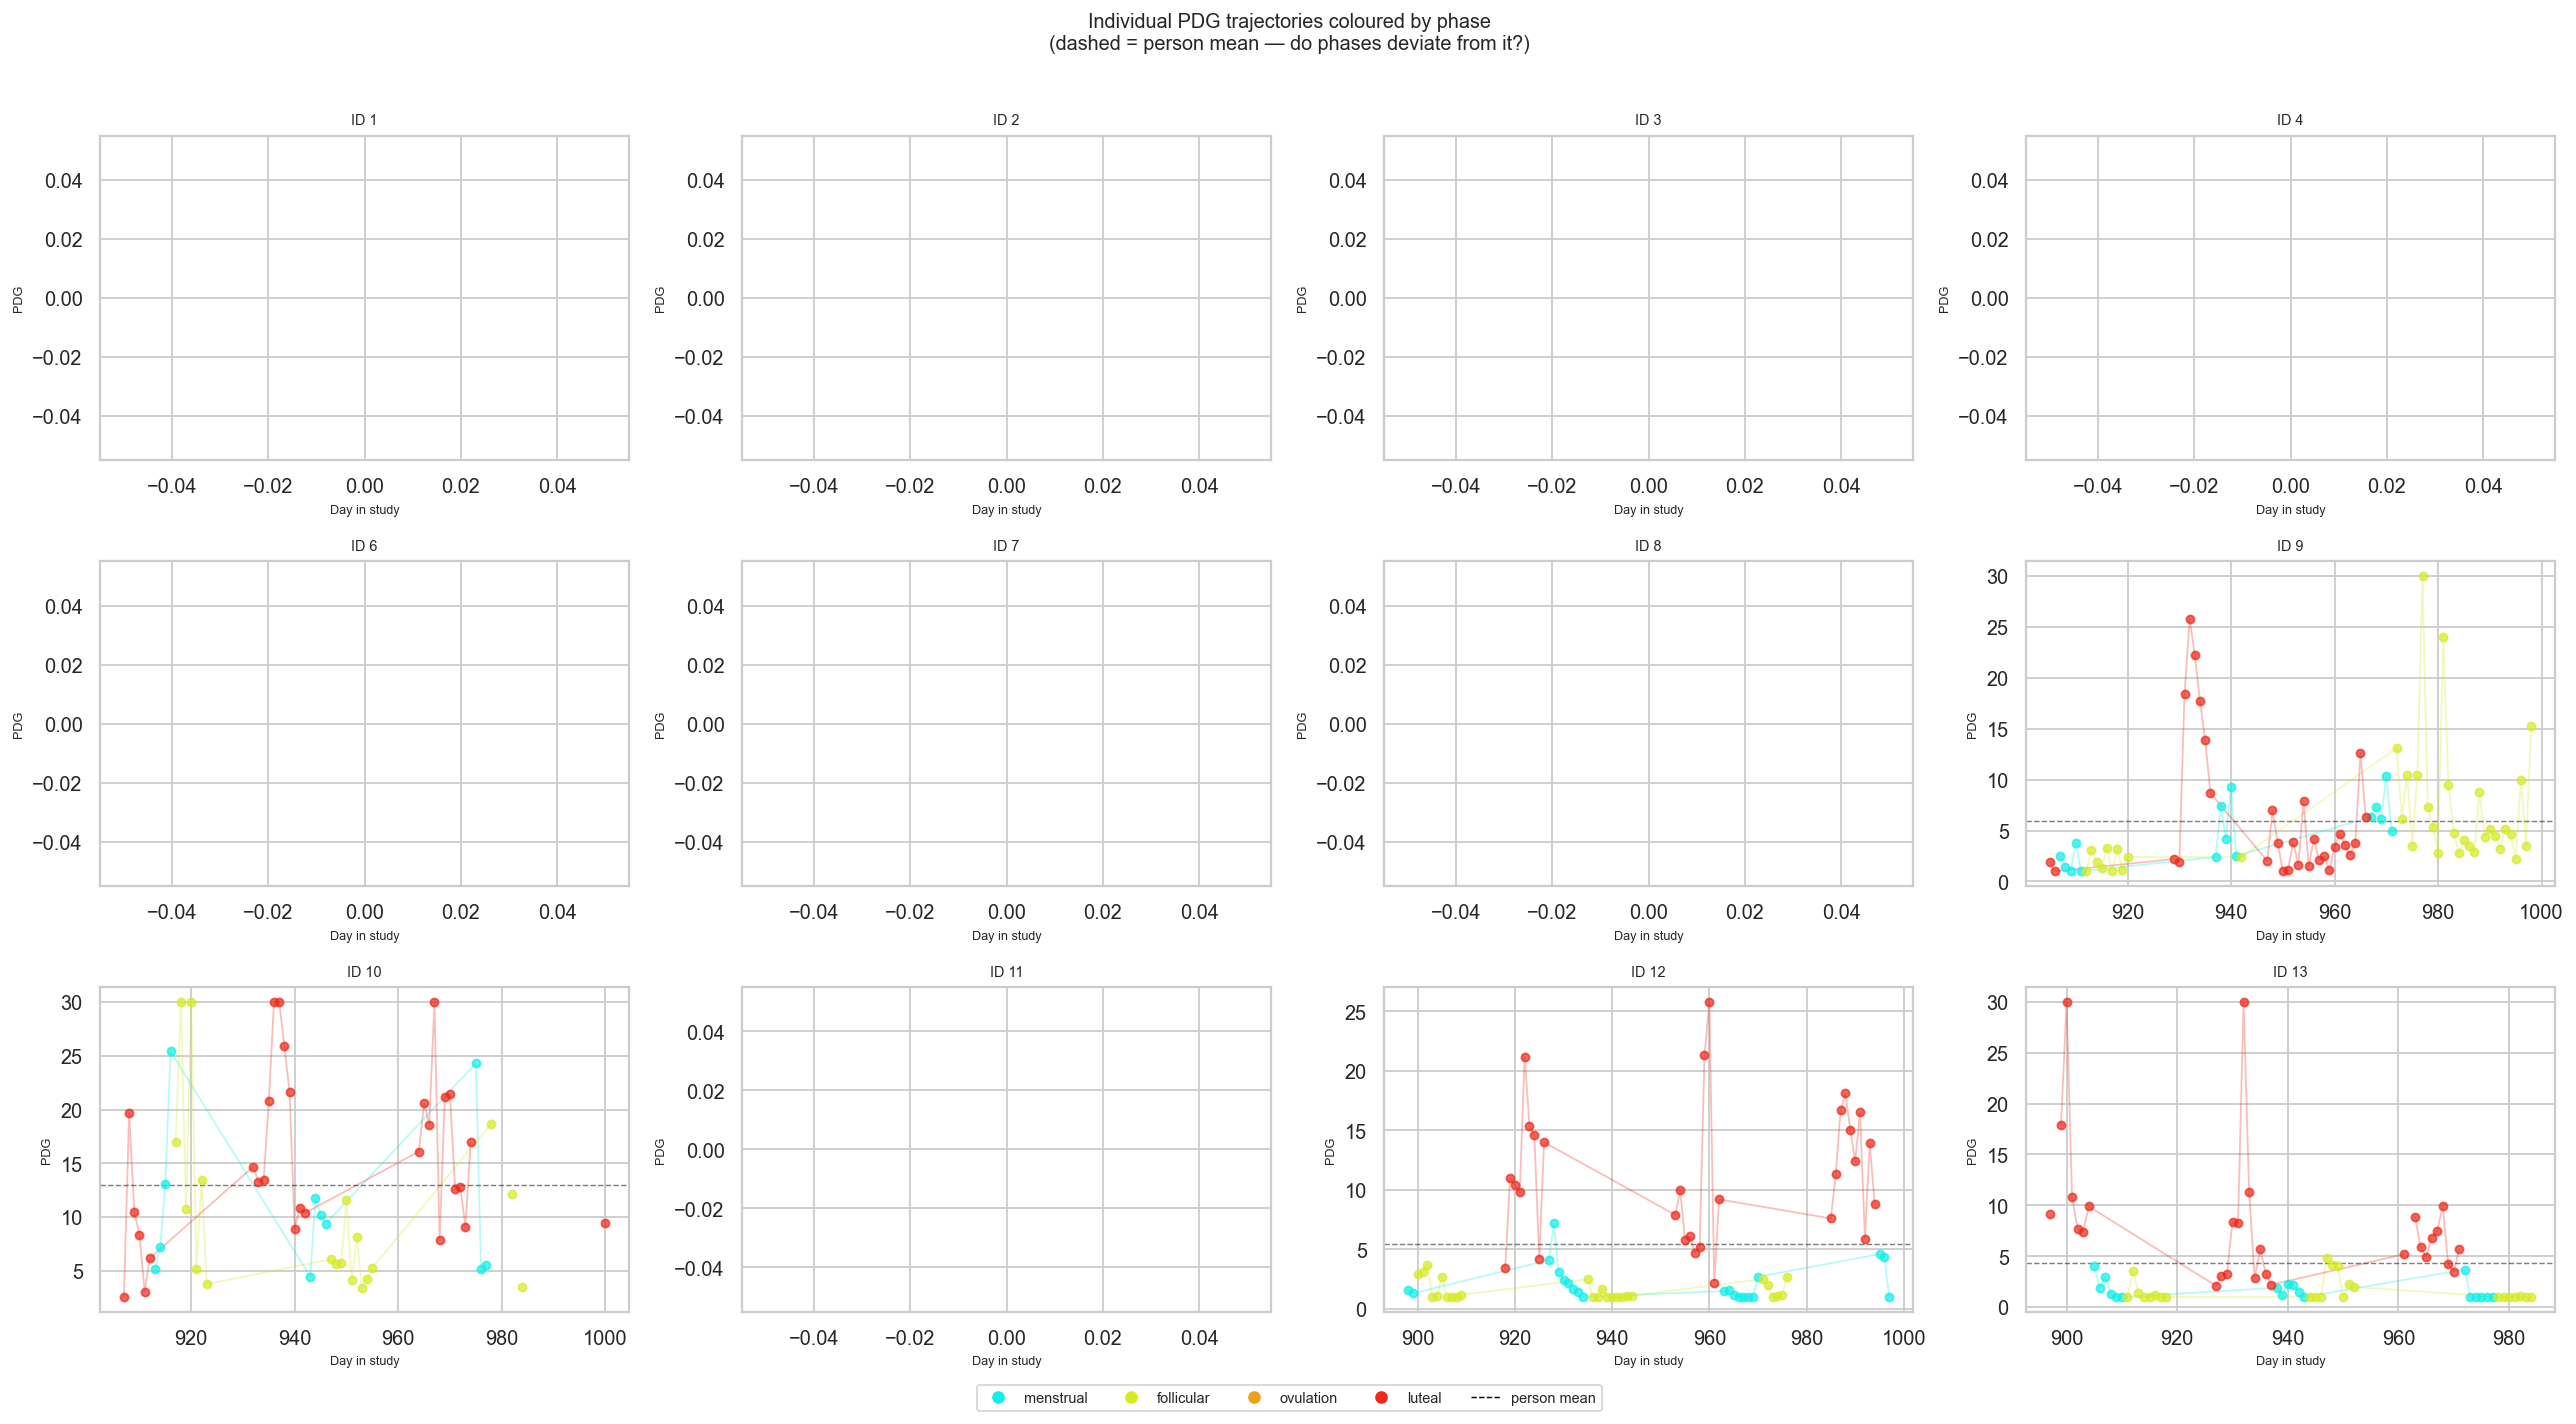

In [35]:
for hormone in hormone_cols:
    participants = hormones[ID_COL].unique()[:12]  # first 12 for readability
    ncols = 4
    nrows = math.ceil(len(participants) / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(5 * ncols, 3.5 * nrows),
                              sharex=False, sharey=False)
    axes = axes.flat

    for ax, pid in zip(axes, participants):
        pdata = hormones[hormones[ID_COL] == pid].sort_values(DAY_COL)
        if pdata.empty or hormone not in pdata.columns:
            ax.set_visible(False)
            continue

        for phase in PHASE_ORDER:
            seg = pdata[pdata["phase"] == phase]
            if seg.empty:
                continue
            ax.scatter(seg[DAY_COL], seg[hormone],
                       color=PHASE_COLORS[phase],
                       s=20, alpha=0.7, label=phase, zorder=3)
            # Connect dots within same phase
            ax.plot(seg[DAY_COL], seg[hormone],
                    color=PHASE_COLORS[phase], alpha=0.3, linewidth=1)

        # Add participant mean as dashed horizontal line
        pmean = pdata[hormone].mean()
        ax.axhline(pmean, color="black", linestyle="--",
                   linewidth=0.8, alpha=0.5)
        ax.set_title(f"ID {pid}", fontsize=8)
        ax.set_xlabel("Day in study", fontsize=7)
        ax.set_ylabel(hormone.upper(), fontsize=7)

    # One shared legend
    legend_handles = [
        mlines.Line2D([], [], color=PHASE_COLORS[p], marker="o",
                      linestyle="None", markersize=6, label=p)
        for p in PHASE_ORDER
    ]
    legend_handles.append(
        mlines.Line2D([], [], color="black", linestyle="--",
                      linewidth=0.8, label="person mean")
    )
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=5, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(f"Individual {hormone.upper()} trajectories coloured by phase\n"
                 "(dashed = person mean — do phases deviate from it?)",
                 fontsize=11, y=1.01)
    savefig(f"1d_{hormone}_individual_trajectories.png")

In [36]:
# ══════════════════════════════════════════════════════════════
# PART 2 — AFTER JOINING WEARABLE SIGNALS TO PHASE TABLE
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("PART 2 — WEARABLE SIGNALS × PHASE (after join)")
print("="*60)


PART 2 — WEARABLE SIGNALS × PHASE (after join)


In [37]:
# ── Daily aggregations of wearable tables ─────────────────────────────────────
def daily_agg(df, agg_dict):
    cols = JOIN_KEYS + list(agg_dict.keys())
    df   = df[[c for c in cols if c in df.columns]].copy()
    out  = df.groupby(JOIN_KEYS).agg(agg_dict).reset_index()
    out.columns = ["_".join(c).strip("_") if isinstance(c, tuple) else c
                   for c in out.columns]
    return out

In [38]:
daily_stress  = stress[["id","day_in_study","study_interval","stress_score"]].copy()
daily_sleepsc = sleep_score[["id","day_in_study","study_interval",
                              "overall_score","deep_sleep_in_minutes",
                              "restlessness"]].copy()
daily_rhr     = resting_hr[["id","day_in_study","study_interval","value"]].copy()
daily_rhr     = daily_rhr.rename(columns={"value": "resting_hr"})
daily_active  = daily_agg(active_min,
                           {"sedentary": "mean", "lightly": "mean",
                            "moderately": "mean", "very": "mean"})
daily_cal     = daily_agg(calories, {"calories": "sum"})
daily_glucose = daily_agg(glucose_df,
                           {"glucose_value": ["mean", "std"]})
daily_steps   = daily_agg(steps_df, {"steps": "sum"})

In [39]:
# ── Join all wearable signals to phase table ──────────────────────────────────
phase_master = (
    hormones
    .merge(daily_stress,   on=JOIN_KEYS, how="left")
    .merge(daily_sleepsc,  on=JOIN_KEYS, how="left")
    .merge(daily_rhr,      on=JOIN_KEYS, how="left")
    .merge(daily_active,   on=JOIN_KEYS, how="left")
    .merge(daily_cal,      on=JOIN_KEYS, how="left")
    .merge(daily_glucose,  on=JOIN_KEYS, how="left")
    .merge(daily_steps,    on=JOIN_KEYS, how="left")
)
print(f"\nPhase master shape: {phase_master.shape}")


Phase master shape: (15587, 35)


In [40]:
# ── 2a. Wearable signals by phase — box plots ─────────────────────────────────
wearable_signals = {
    "stress_score"      : "Fitbit stress score",
    "overall_score"     : "Sleep score",
    "resting_hr"        : "Resting HR (bpm)",
    "moderately"        : "Moderate active minutes",
    "very"              : "Very active minutes",
    "calories"          : "Daily calories burned",
    "glucose_value_mean": "Mean glucose (mmol/L)",
}

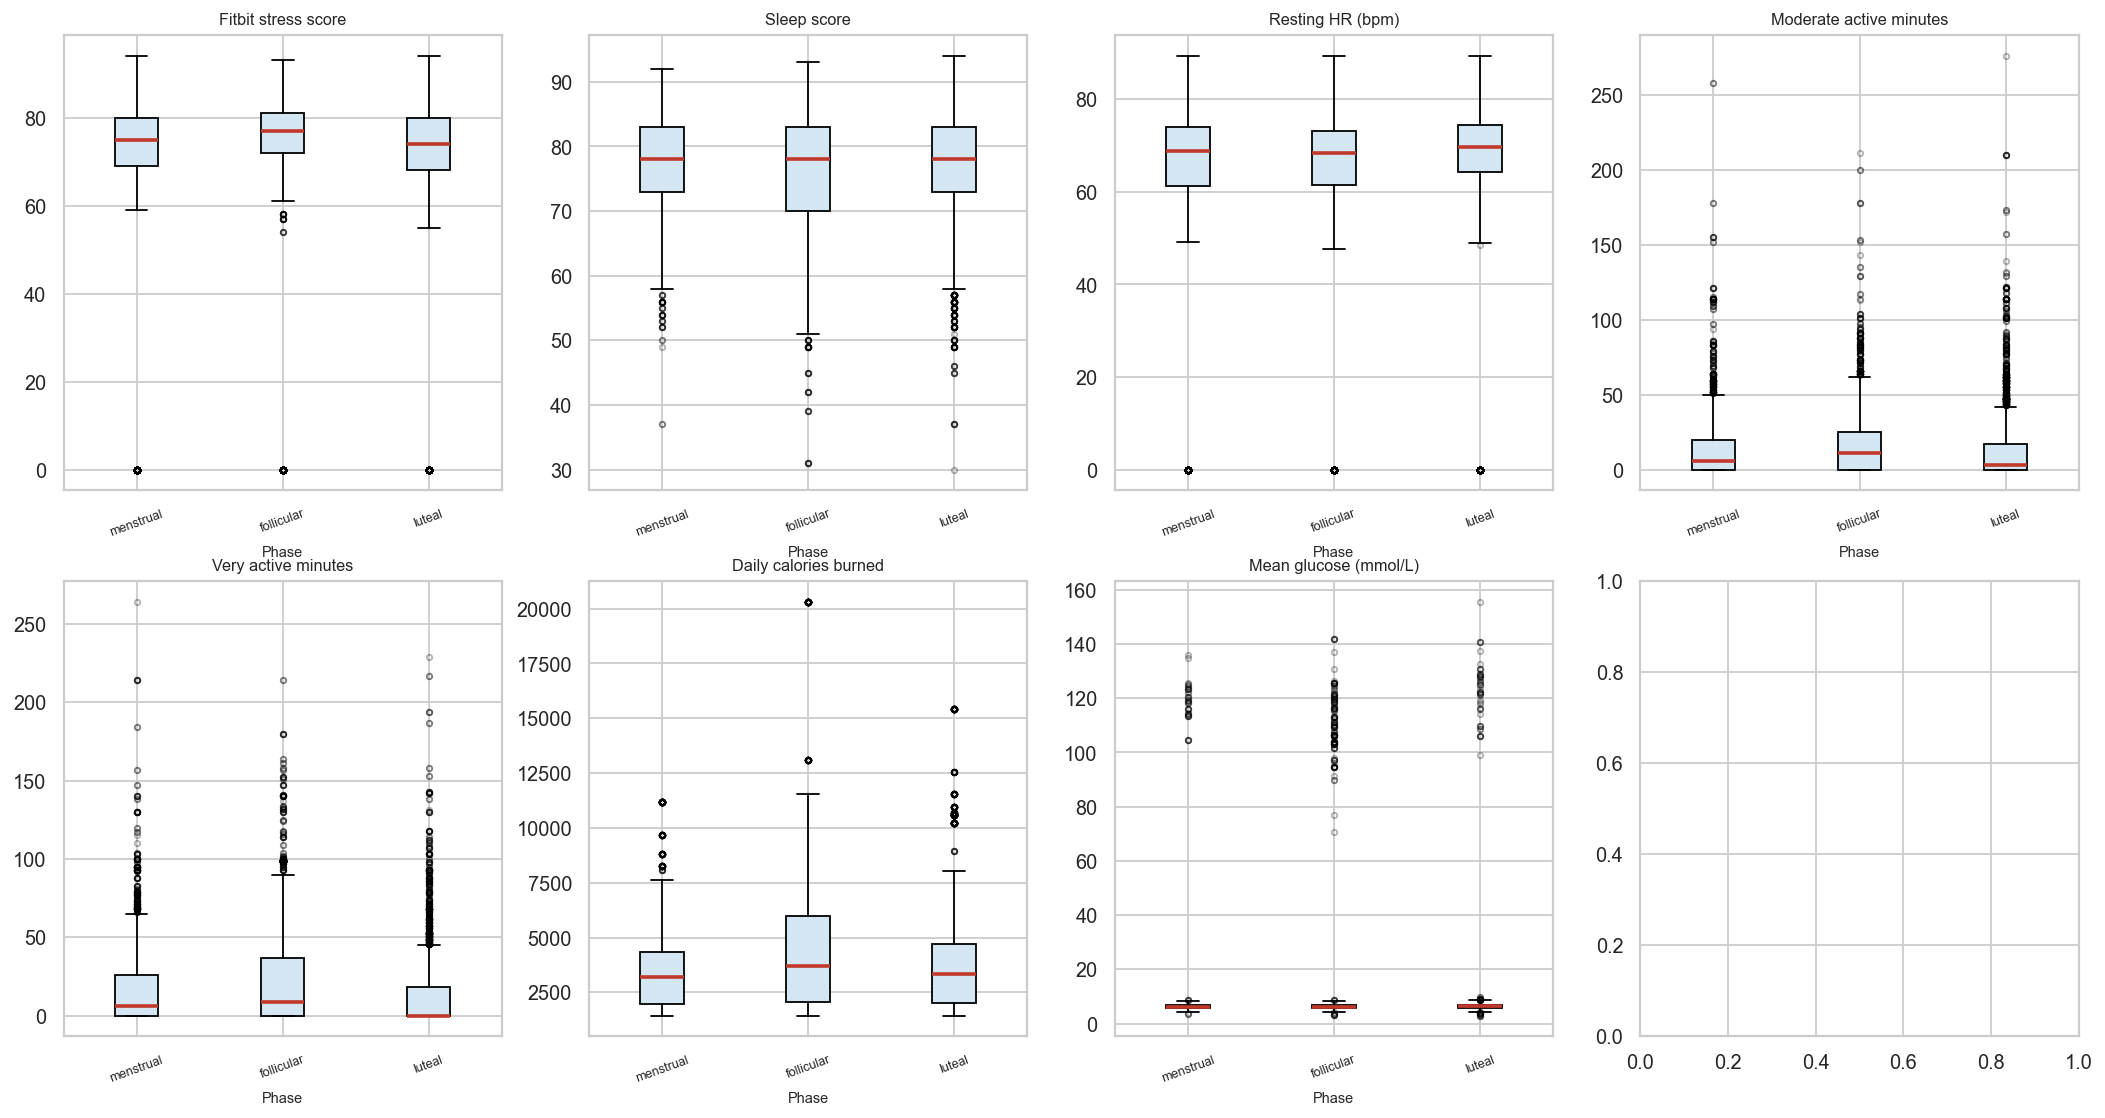

In [41]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (col, label) in zip(axes.flat, wearable_signals.items()):
    if col not in phase_master.columns:
        ax.set_visible(False)
        continue

    phase_data = [
        phase_master[phase_master["phase"] == p][col].dropna()
        for p in PHASE_ORDER
        if p in phase_master["phase"].unique()
    ]
    valid_phases = [p for p in PHASE_ORDER
                    if p in phase_master["phase"].unique()]

    ax.boxplot(phase_data,
               labels=valid_phases,
               patch_artist=True,
               boxprops=dict(facecolor="#d4e6f1"),
               medianprops=dict(color="#c0392b", linewidth=2),
               flierprops=dict(marker="o", markersize=3, alpha=0.3))

    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Phase", fontsize=8)
    ax.tick_params(axis="x", rotation=20, labelsize=7)

In [42]:
plt.suptitle("Wearable signals across menstrual phases\n"
             "(red line = median; these are RAW, not baseline-adjusted)",
             fontsize=12, y=1.02)
savefig("2a_wearables_by_phase.png")

<Figure size 832x624 with 0 Axes>

── 2b. INTRA-PERSON PHASE BASELINE SHIFT ─────────────────────────────────────
Core of the hypothesis: does each person's baseline shift by phase?
Method: for each participant × signal, compare mean per phase.
Statistical test: Friedman test (non-parametric repeated measures).
If significant → that person's signal varies meaningfully by phase.

In [43]:
print("\n" + "-"*50)
print("2b. Intra-person phase baseline shift — Friedman test")
print("-"*50)


--------------------------------------------------
2b. Intra-person phase baseline shift — Friedman test
--------------------------------------------------


In [44]:
SIGNALS_TO_TEST = ["stress_score", "overall_score", "resting_hr",
                   "moderately", "very", "calories", "glucose_value_mean"]
SIGNALS_TO_TEST = [s for s in SIGNALS_TO_TEST if s in phase_master.columns]

In [45]:
friedman_results = []

In [46]:
for pid in phase_master[ID_COL].unique():
    pdata = phase_master[phase_master[ID_COL] == pid]

    for sig in SIGNALS_TO_TEST:
        groups = [
            pdata[pdata["phase"] == p][sig].dropna().values
            for p in PHASE_ORDER
            if p in pdata["phase"].unique()
        ]
        # Need at least 3 phases and ≥2 observations each
        valid_groups = [g for g in groups if len(g) >= 2]
        if len(valid_groups) < 3:
            continue
        # Truncate to same length for Friedman
        min_n = min(len(g) for g in valid_groups)
        trimmed = [g[:min_n] for g in valid_groups]
        try:
            stat, p = friedmanchisquare(*trimmed)
            friedman_results.append({
                "id": pid, "signal": sig,
                "friedman_stat": stat, "p_value": p,
                "significant": p < 0.05
            })
        except Exception:
            pass

signal
calories              0.571429
glucose_value_mean    0.609756
moderately            0.476190
overall_score         0.380952
resting_hr            0.690476
stress_score          0.694444
very                  0.619048


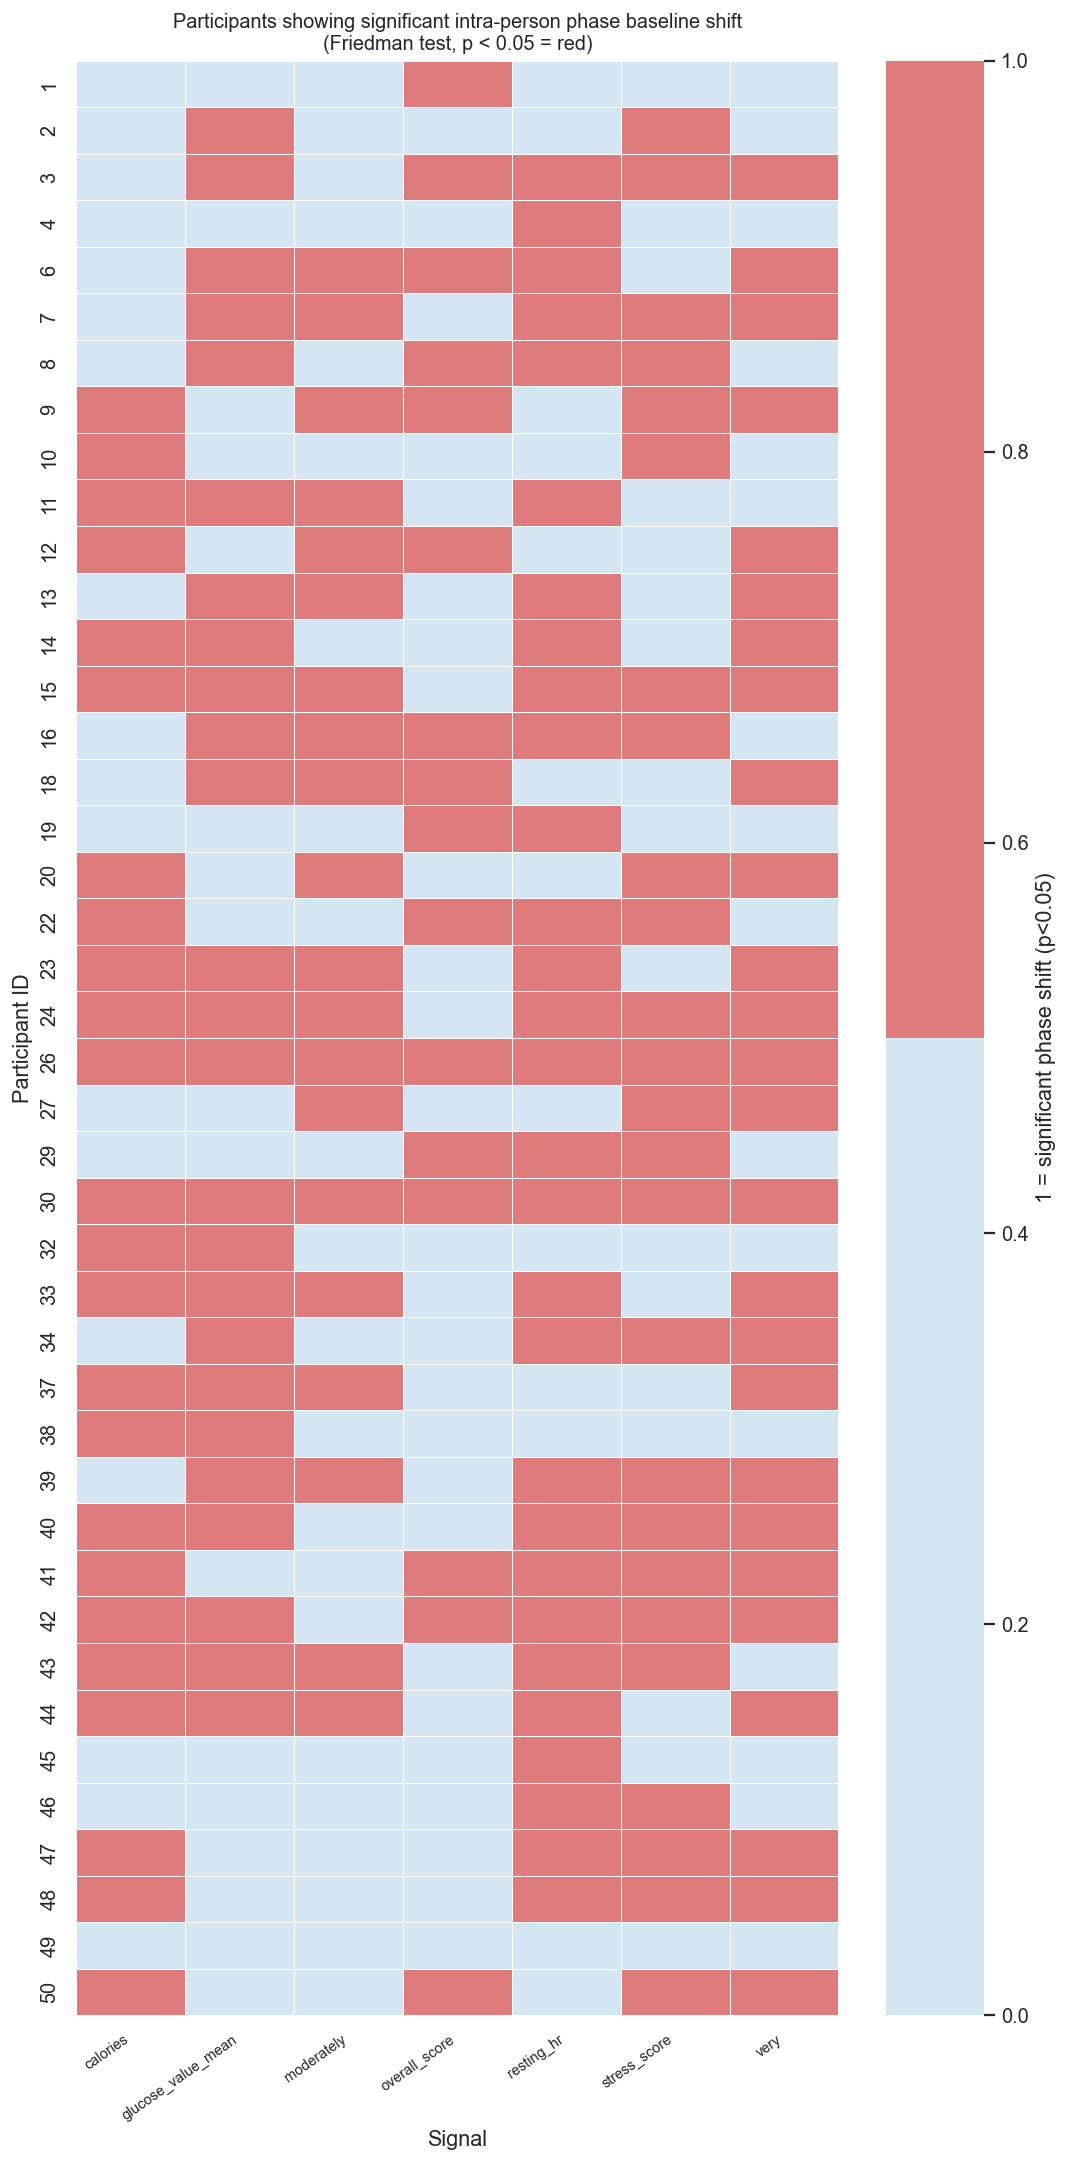

In [47]:
friedman_df = pd.DataFrame(friedman_results)
if not friedman_df.empty:
    print(friedman_df.groupby("signal")["significant"].mean()
          .rename("fraction_of_participants_significant")
          .to_string())

    # Heatmap: which participants × signals show significant phase shifts?
    pivot = friedman_df.pivot_table(
        index="id", columns="signal",
        values="p_value", aggfunc="min"
    )
    sig_mask = pivot < 0.05

    fig, ax = plt.subplots(figsize=(max(8, len(SIGNALS_TO_TEST) * 1.2),
                                     max(6, len(pivot) * 0.4)))
    sns.heatmap(sig_mask.astype(int), ax=ax,
                cmap=["#d4e6f1", "#e07b7b"],
                linewidths=0.5,
                cbar_kws={"label": "1 = significant phase shift (p<0.05)"},
                xticklabels=True, yticklabels=True)
    ax.set_title("Participants showing significant intra-person phase baseline shift\n"
                 "(Friedman test, p < 0.05 = red)", fontsize=11)
    ax.set_xlabel("Signal")
    ax.set_ylabel("Participant ID")
    plt.xticks(rotation=35, ha="right", fontsize=8)
    savefig("2b_friedman_heatmap.png")

── 2c. PHASE-RELATIVE DEVIATION PLOTS ────────────────────────────────────────
For each signal: compute person's mean per phase, then
  deviation = observed − person's own phase mean
This isolates within-phase variability from the phase shift itself.
KEY INSIGHT: if deviation is small but phase means differ → clean phase effect
If deviation is large → noisy within phase (harder to model)

In [48]:
print("\n2c. Phase-relative deviation analysis …")


2c. Phase-relative deviation analysis …


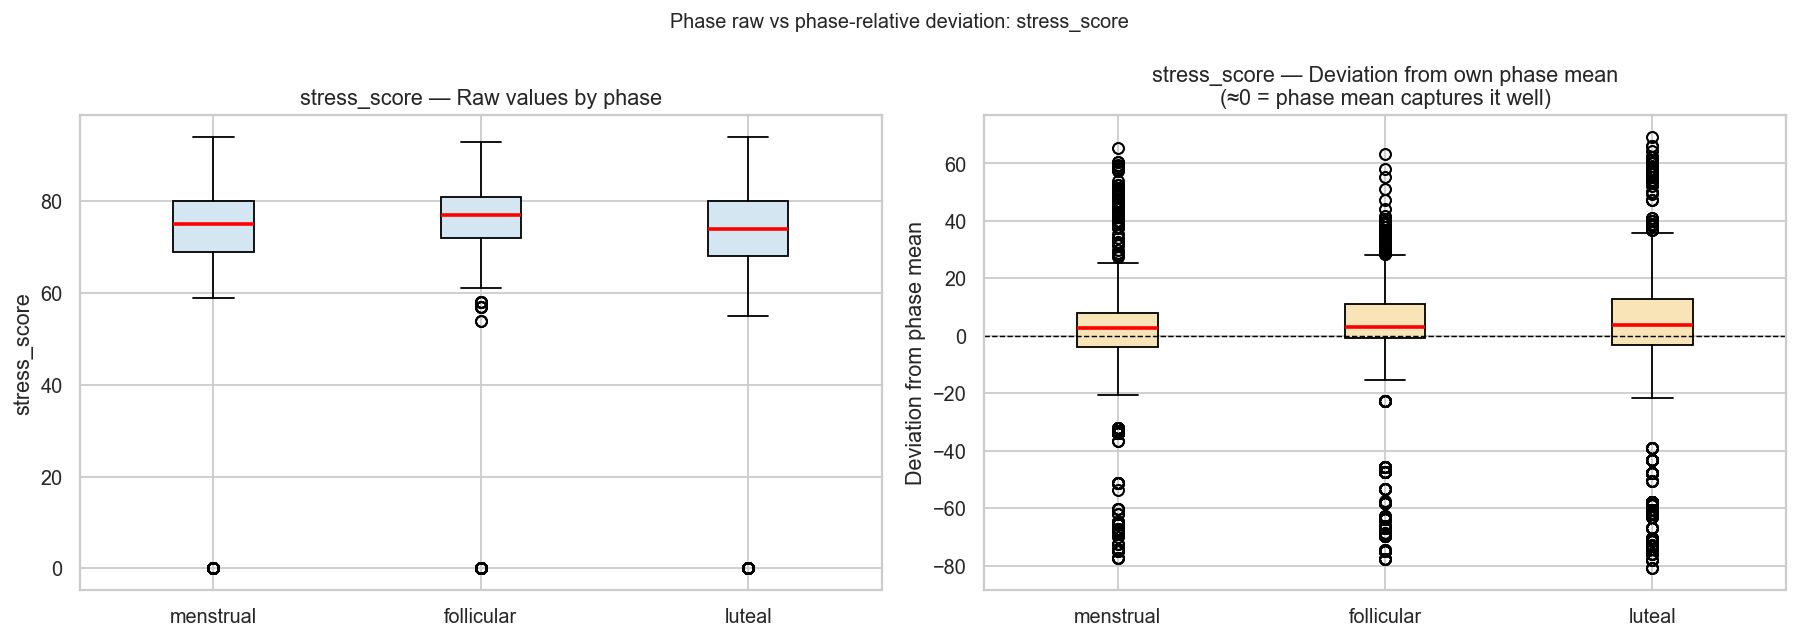

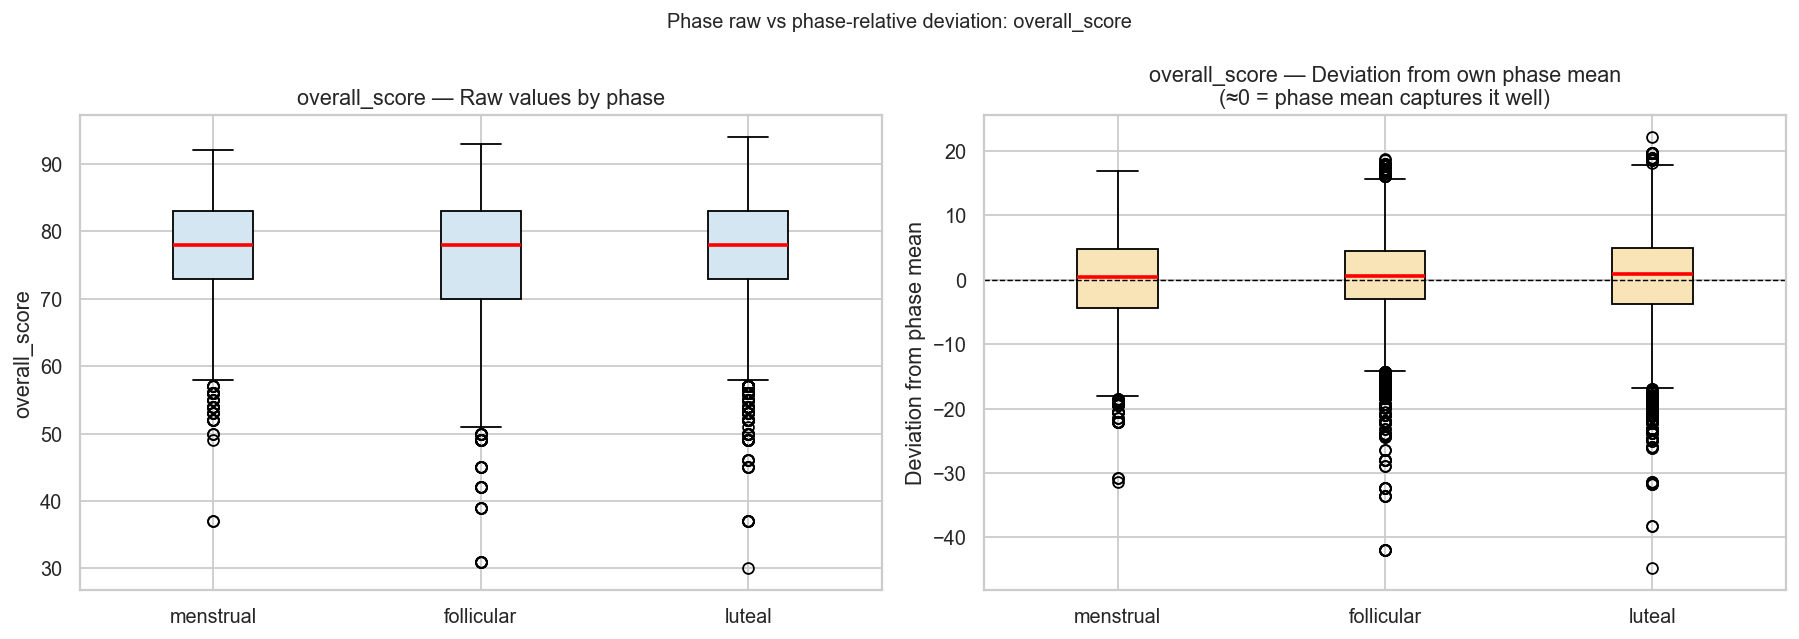

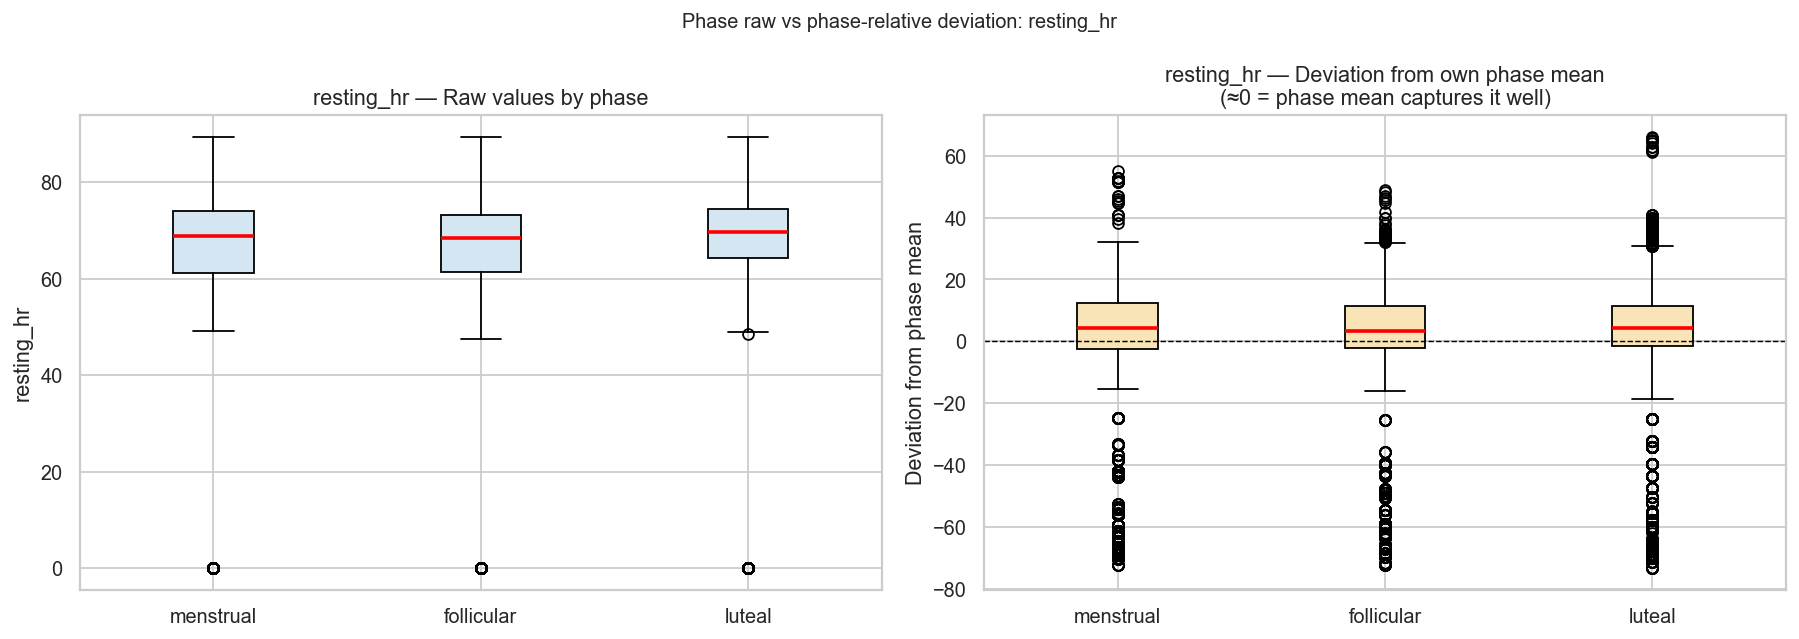

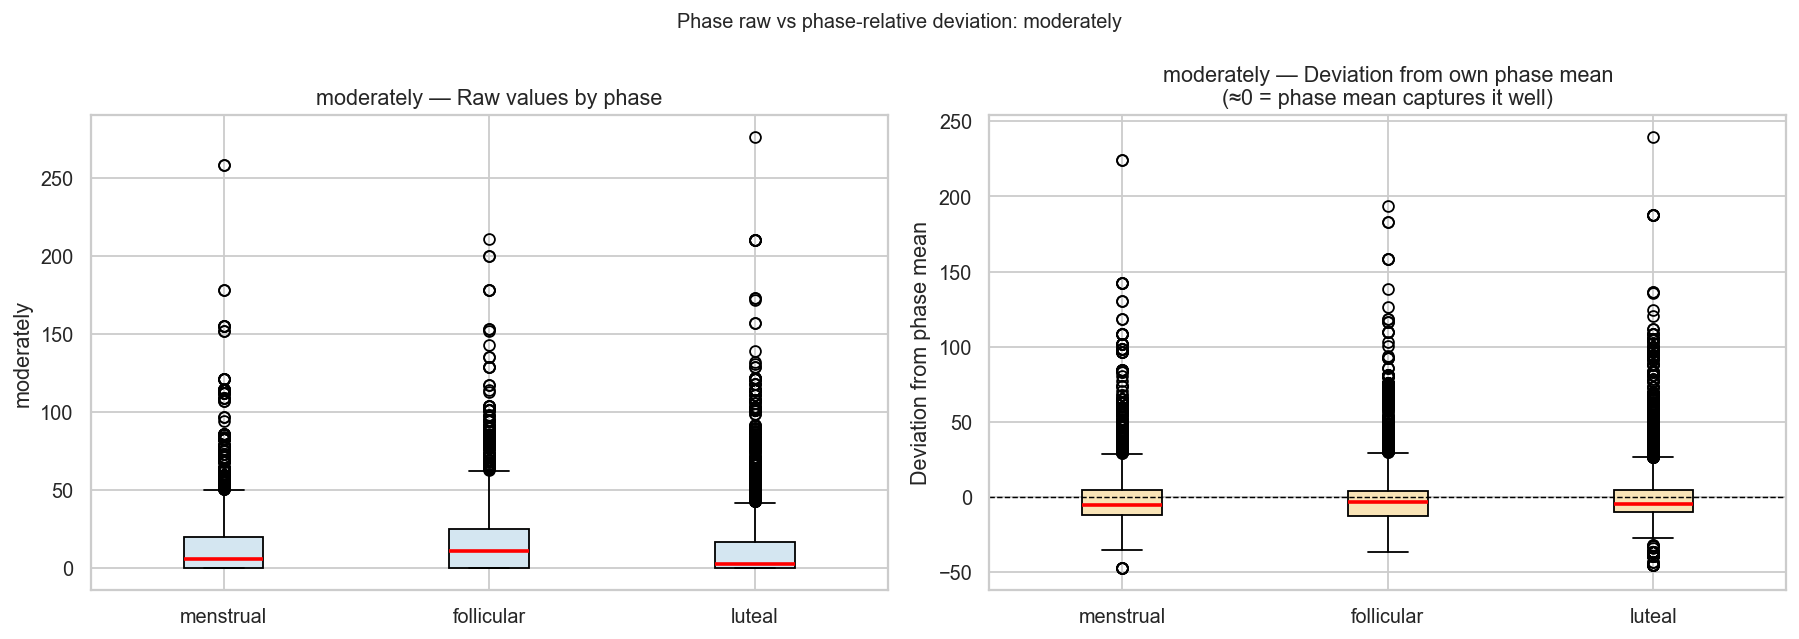

In [49]:
for sig in SIGNALS_TO_TEST[:4]:   # first 4 signals for brevity
    if sig not in phase_master.columns:
        continue

    # Compute person × phase mean
    phase_means = (
        phase_master.groupby([ID_COL, "phase"])[sig]
                    .mean()
                    .rename("phase_mean")
                    .reset_index()
    )
    pm2 = phase_master.merge(phase_means, on=[ID_COL, "phase"], how="left")
    pm2[f"{sig}_phase_deviation"] = pm2[sig] - pm2["phase_mean"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: raw signal by phase
    phase_data_raw = [
        pm2[pm2["phase"] == p][sig].dropna()
        for p in PHASE_ORDER if p in pm2["phase"].unique()
    ]
    axes[0].boxplot(phase_data_raw,
                    labels=[p for p in PHASE_ORDER
                            if p in pm2["phase"].unique()],
                    patch_artist=True,
                    boxprops=dict(facecolor="#d4e6f1"),
                    medianprops=dict(color="red", linewidth=2))
    axes[0].set_title(f"{sig} — Raw values by phase")
    axes[0].set_ylabel(sig)

    # Right: deviation from person's own phase mean
    phase_data_dev = [
        pm2[pm2["phase"] == p][f"{sig}_phase_deviation"].dropna()
        for p in PHASE_ORDER if p in pm2["phase"].unique()
    ]
    axes[1].boxplot(phase_data_dev,
                    labels=[p for p in PHASE_ORDER
                            if p in pm2["phase"].unique()],
                    patch_artist=True,
                    boxprops=dict(facecolor="#f9e4b7"),
                    medianprops=dict(color="red", linewidth=2))
    axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[1].set_title(f"{sig} — Deviation from own phase mean\n"
                       "(≈0 = phase mean captures it well)")
    axes[1].set_ylabel("Deviation from phase mean")

    plt.suptitle(f"Phase raw vs phase-relative deviation: {sig}", fontsize=11)
    savefig(f"2c_{sig}_phase_deviation.png")

In [50]:
# ── 2d. Exercise signals by phase — directly informs recommendation ───────────
print("\n2d. Exercise signals by phase …")


2d. Exercise signals by phase …


In [51]:
exercise_signals = {
    "sedentary"  : "Sedentary minutes",
    "lightly"    : "Light active minutes",
    "moderately" : "Moderate active minutes",
    "very"       : "Very active minutes",
    "calories"   : "Calories burned",
    "steps"      : "Daily steps",
}
exercise_signals = {k: v for k, v in exercise_signals.items()
                    if k in phase_master.columns}

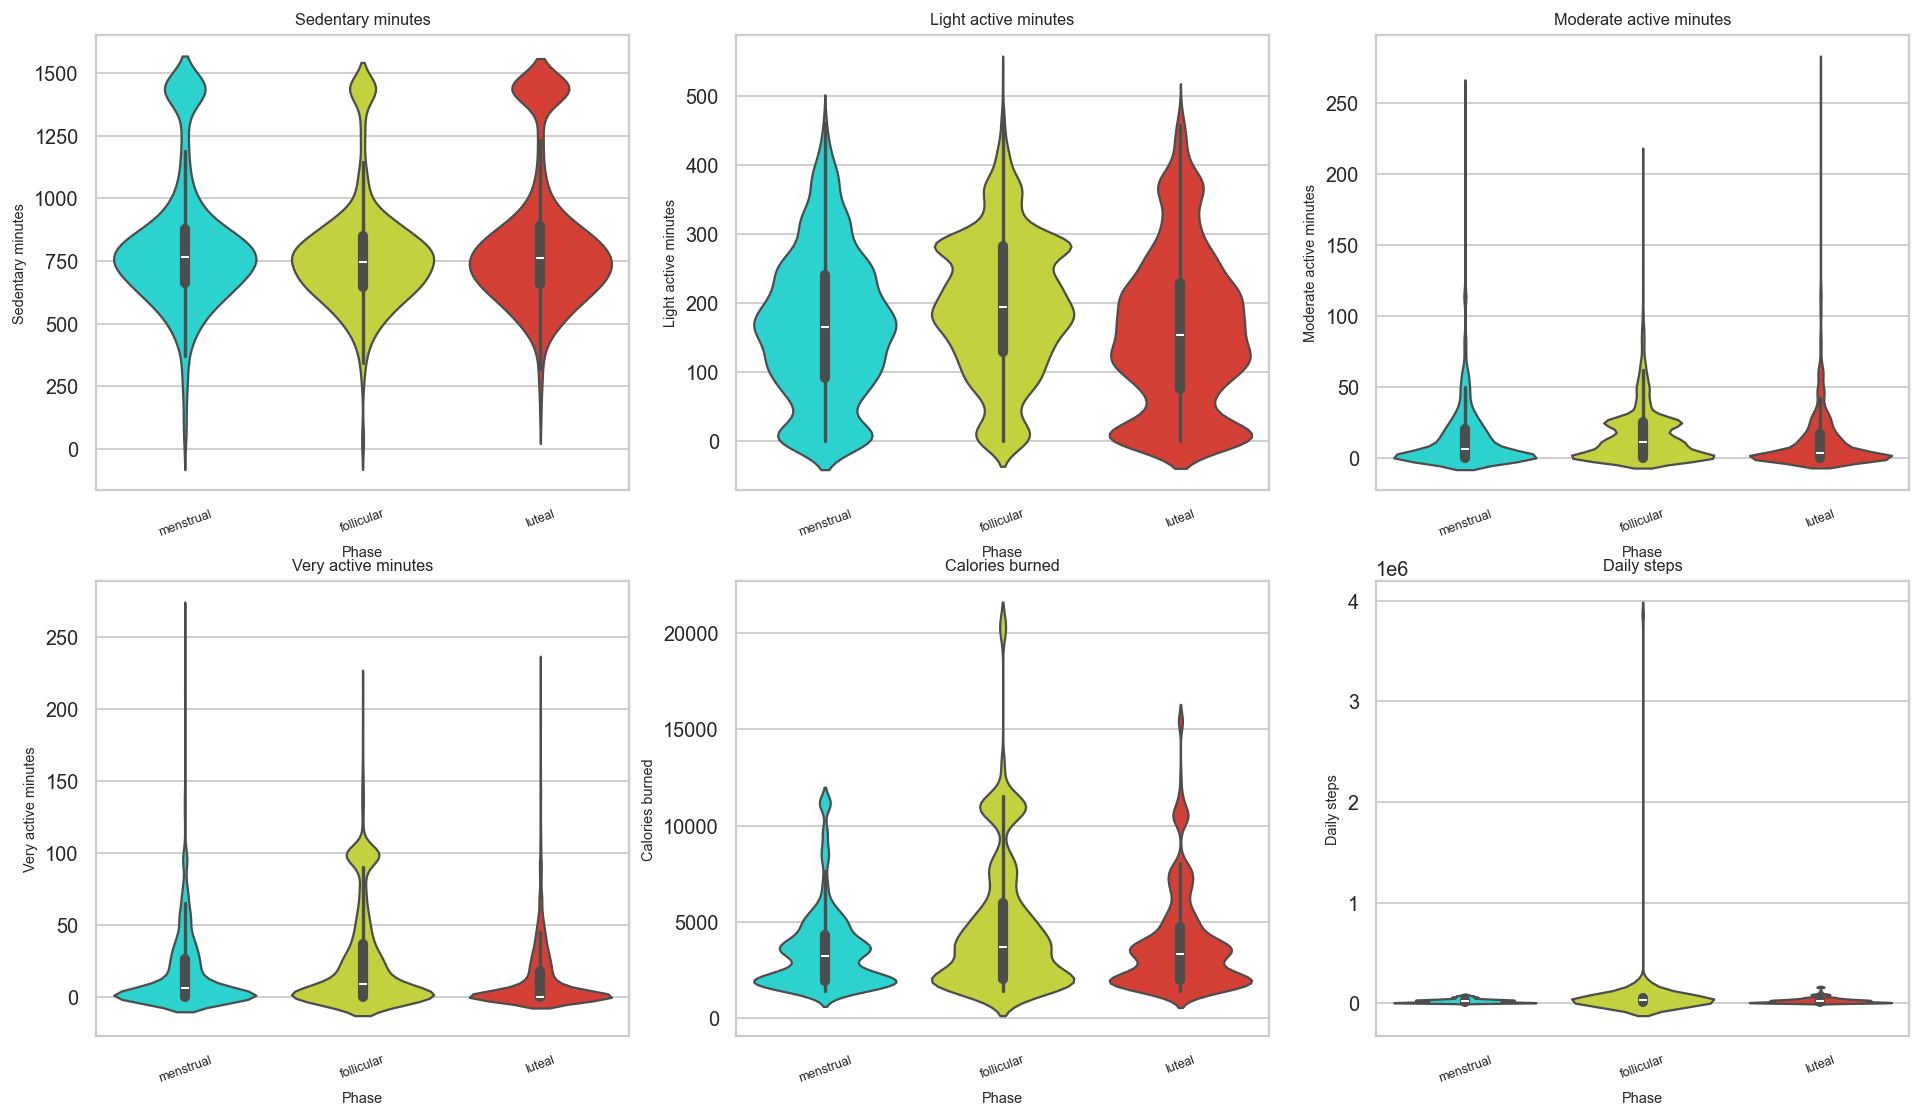

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, label) in zip(axes.flat, exercise_signals.items()):
    # Violin plot — shows full distribution shape, not just IQR
    valid = phase_master[phase_master["phase"].isin(PHASE_ORDER) &
                         phase_master[col].notna()]
    sns.violinplot(data=valid, x="phase", y=col,
                   order=[p for p in PHASE_ORDER
                          if p in valid["phase"].unique()],
                   palette=PHASE_COLORS, ax=ax, inner="box",
                   scale="width")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Phase", fontsize=8)
    ax.set_ylabel(label, fontsize=8)
    ax.tick_params(axis="x", rotation=20, labelsize=7)

In [53]:
plt.suptitle("Exercise & activity signals by menstrual phase\n"
             "(violin = full distribution, inner box = IQR)\n"
             "→ Do participants naturally exercise differently by phase?",
             fontsize=11, y=1.02)
savefig("2d_exercise_by_phase.png")

<Figure size 832x624 with 0 Axes>

── 2e. Individual participant phase trajectories for wearables ───────────────
For each participant, plot their stress and sleep score coloured by phase
to visually confirm intra-person phase baseline shift

In [54]:
print("\n2e. Individual longitudinal phase trajectories …")


2e. Individual longitudinal phase trajectories …


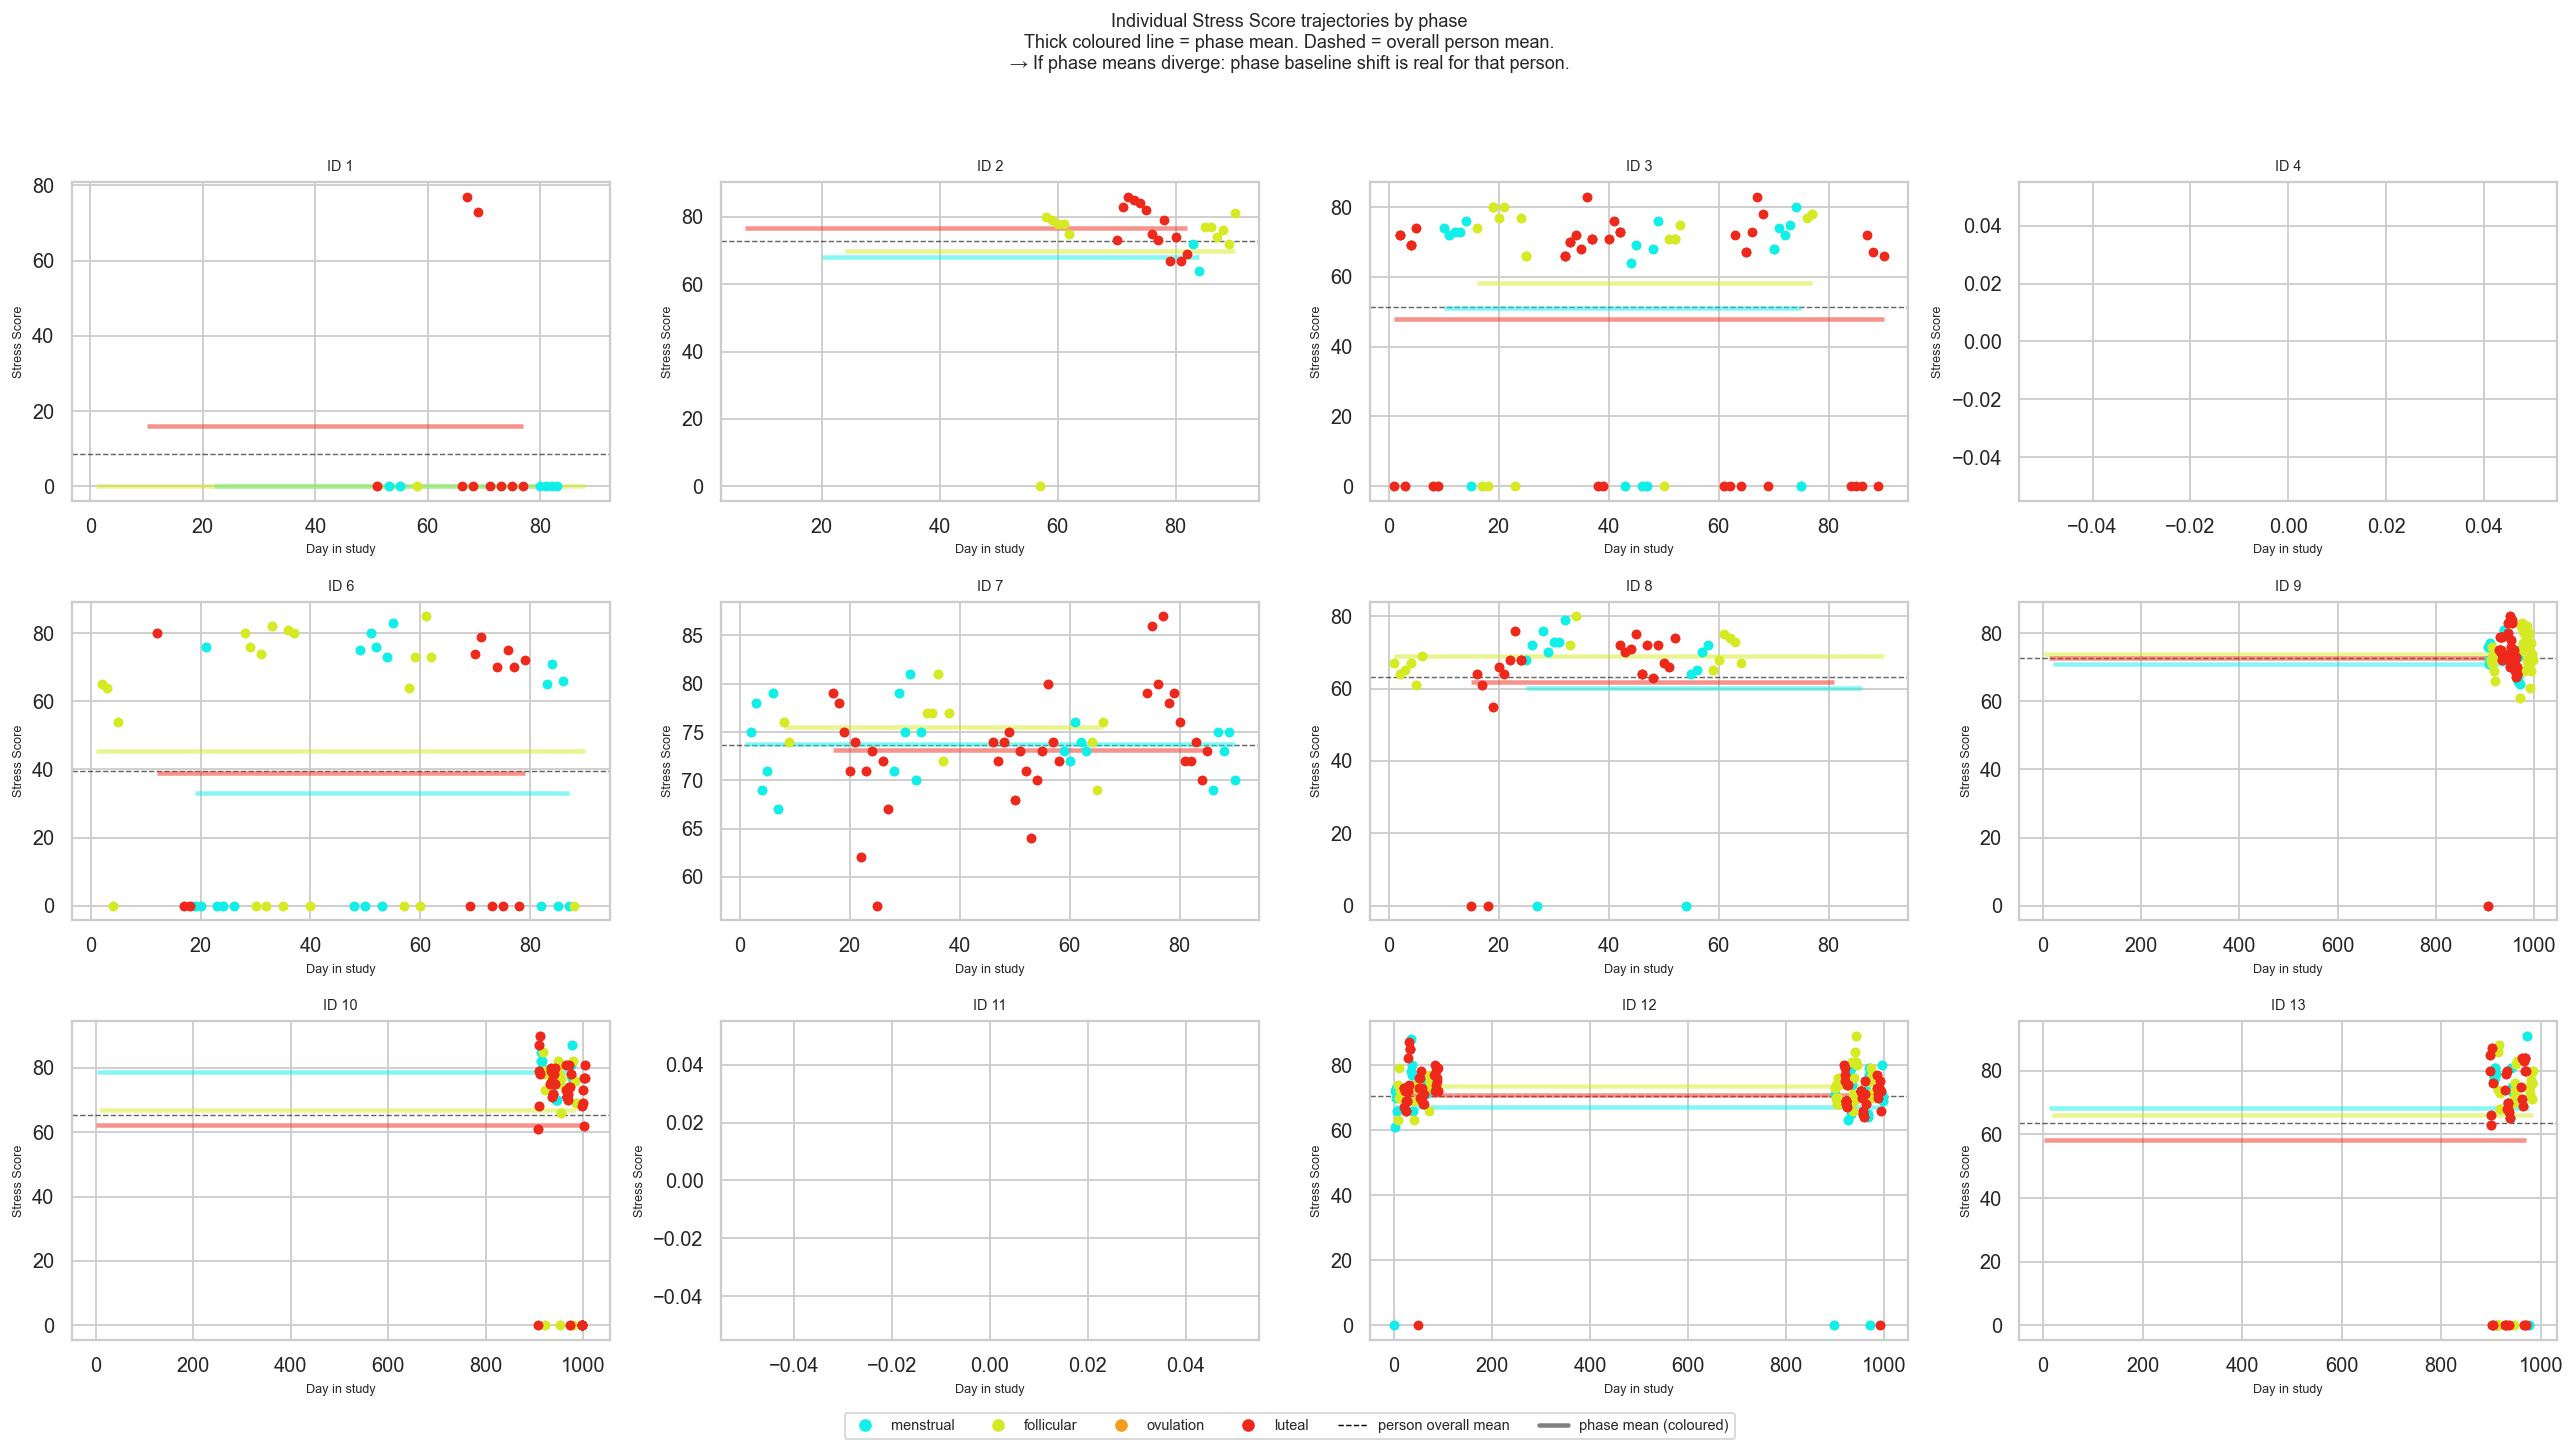

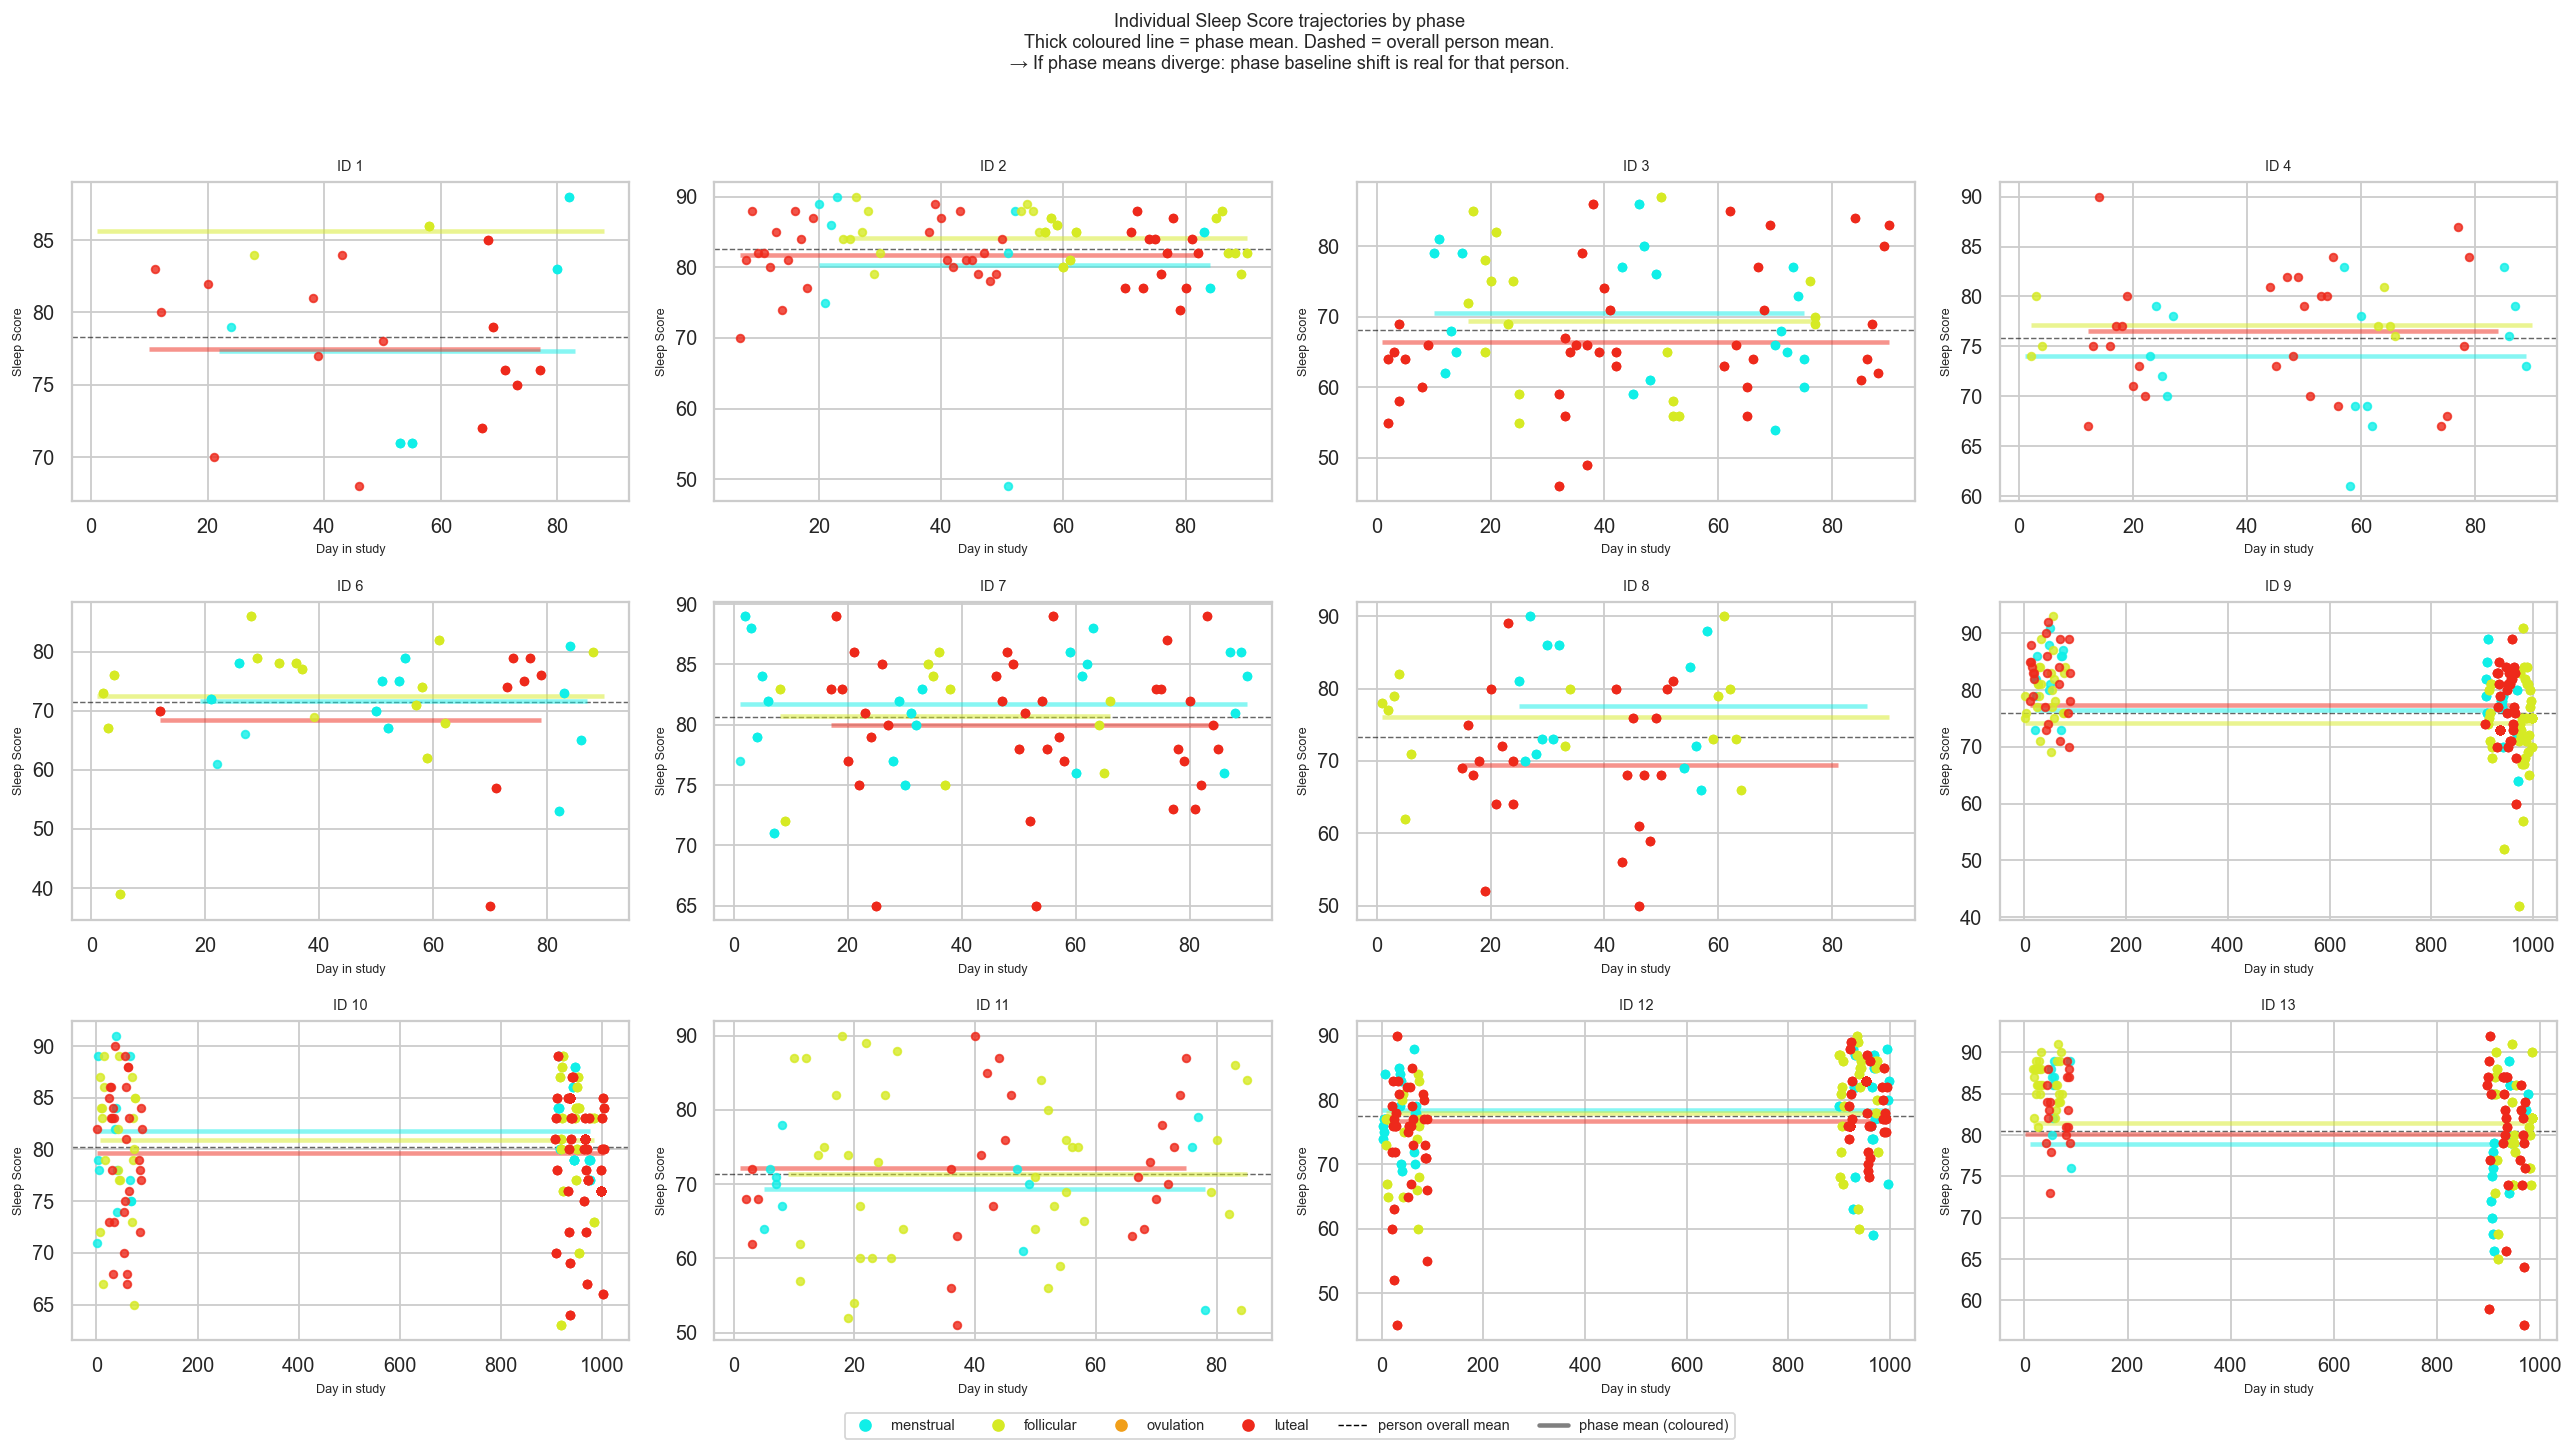

In [55]:
for sig, label in [("stress_score", "Stress Score"),
                   ("overall_score", "Sleep Score")]:
    if sig not in phase_master.columns:
        continue

    participants = phase_master[ID_COL].unique()[:12]
    ncols = 4
    nrows = -(-len(participants) // ncols)  # ceiling div

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(5 * ncols, 3.5 * nrows),
                              sharex=False, sharey=False)
    for ax, pid in zip(axes.flat, participants):
        pdata = phase_master[phase_master[ID_COL] == pid].sort_values(DAY_COL)
        if pdata.empty:
            ax.set_visible(False)
            continue

        # Plot line, colour segments by phase
        for phase in PHASE_ORDER:
            seg = pdata[pdata["phase"] == phase]
            if seg.empty:
                continue
            ax.scatter(seg[DAY_COL], seg[sig],
                       color=PHASE_COLORS[phase], s=18, alpha=0.8,
                       label=phase, zorder=3)

        # Person-level mean
        ax.axhline(pdata[sig].mean(), color="black",
                   linestyle="--", linewidth=0.8, alpha=0.6)

        # Phase-level means as horizontal coloured segments
        for phase in PHASE_ORDER:
            seg = pdata[pdata["phase"] == phase]
            if seg.empty or seg[sig].isna().all():
                continue
            pmean = seg[sig].mean()
            xmin  = seg[DAY_COL].min()
            xmax  = seg[DAY_COL].max()
            ax.hlines(pmean, xmin, xmax,
                      color=PHASE_COLORS[phase],
                      linewidth=2.5, alpha=0.5, linestyle="-")

        ax.set_title(f"ID {pid}", fontsize=8)
        ax.set_xlabel("Day in study", fontsize=7)
        ax.set_ylabel(label, fontsize=7)

    legend_handles = [
        mlines.Line2D([], [], color=PHASE_COLORS[p], marker="o",
                      linestyle="None", markersize=6, label=p)
        for p in PHASE_ORDER
    ] + [
        mlines.Line2D([], [], color="black", linestyle="--",
                      linewidth=0.8, label="person overall mean"),
        mlines.Line2D([], [], color="grey", linestyle="-",
                      linewidth=2.5, label="phase mean (coloured)")
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle(
        f"Individual {label} trajectories by phase\n"
        "Thick coloured line = phase mean. Dashed = overall person mean.\n"
        "→ If phase means diverge: phase baseline shift is real for that person.",
        fontsize=10, y=1.03
    )
    savefig(f"2e_{sig}_individual_phase_trajectories.png")

In [56]:
print(f"\n✓ Script 2 complete. Figures saved to: {os.path.abspath(OUT_DIR)}")


✓ Script 2 complete. Figures saved to: /Users/kikkiliu/physionet.org/files/mcphases/eda_outputs/script2_phase
